In [1]:
# COMPLETE BIRD PEST DETECTION SYSTEM

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. DATA PREPROCESSING FUNCTIONS
# ============================================================================

def load_and_pad_audio(file_path, target_sr=16000, target_duration=5.0):
    """
    Load audio file and pad/trim to target duration
    """
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=target_sr)
        
        # Calculate target length
        target_length = int(target_sr * target_duration)
        
        # Pad or trim audio
        if len(y) > target_length:
            y = y[:target_length]
        elif len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        
        return y, target_sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

def extract_mel_energy(y, sr, n_mels=32, n_fft=1024, hop_length=512):
    """
    Extract mel frequency energy features
    """
    # Extract mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y, 
        sr=sr, 
        n_mels=n_mels, 
        n_fft=n_fft, 
        hop_length=hop_length,
        fmin=50,
        fmax=8000
    )
    
    # Convert to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalize to [0, 1]
    mel_normalized = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
    
    return mel_normalized

def process_audio_dataset(data_path, target_sr=16000, target_duration=5.0, 
                         n_mels=32, n_fft=1024, hop_length=512):
    """
    Process entire audio dataset
    """
    print(f"🎵 Processing audio dataset from: {data_path}")
    
    # Get class names from folder structure
    class_names = sorted([d for d in os.listdir(data_path) 
                         if os.path.isdir(os.path.join(data_path, d))])
    
    print(f"📂 Found {len(class_names)} classes: {class_names}")
    
    # Collect file paths and labels
    file_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_path, class_name)
        class_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.wav', '.mp3', '.flac'))]
        
        for file_name in class_files:
            file_paths.append(os.path.join(class_path, file_name))
            labels.append(class_idx)
        
        print(f"   {class_name}: {len(class_files)} files")
    
    print(f"📊 Total files: {len(file_paths)}")
    
    # Process audio files
    features = []
    processed_labels = []
    
    print("🔄 Extracting mel energy features...")
    for file_path, label in tqdm(zip(file_paths, labels), total=len(file_paths)):
        # Load and pad audio
        y, sr = load_and_pad_audio(file_path, target_sr, target_duration)
        
        if y is not None:
            # Extract mel energy features
            mel_features = extract_mel_energy(y, sr, n_mels, n_fft, hop_length)
            
            # Add channel dimension (H, W, C)
            mel_features = np.expand_dims(mel_features, axis=-1)
            
            features.append(mel_features)
            processed_labels.append(label)
    
    # Convert to numpy arrays
    features = np.array(features)
    processed_labels = np.array(processed_labels)
    
    print(f"✅ Processed {len(features)} samples")
    print(f"📏 Features shape: {features.shape}")
    print(f"🏷️ Labels shape: {processed_labels.shape}")
    
    return features, processed_labels, class_names

def prepare_data_for_training(features, labels, test_size=0.2, val_size=0.2, random_state=42):
    """
    Split data into train/validation/test sets
    """
    print("🔧 Preparing data for training...")
    
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        features, labels, test_size=test_size, random_state=random_state, stratify=labels
    )
    
    # Second split: separate train and validation
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
    )
    
    # Convert to categorical
    num_classes = len(np.unique(labels))
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
    y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)
    
    print(f"   Training: {X_train.shape[0]} samples")
    print(f"   Validation: {X_val.shape[0]} samples") 
    print(f"   Test: {X_test.shape[0]} samples")
    
    return X_train, X_val, X_test, y_train_cat, y_val_cat, y_test_cat, y_train, y_val, y_test

# ============================================================================
# 2. MODEL ARCHITECTURES
# ============================================================================

class EnhancedMicroDSCBlock(layers.Layer):
    """
    Enhanced Microcontroller-optimized Depthwise Separable Convolution Block
    """
    def __init__(self, filters, kernel_size=3, strides=1, use_residual=False, **kwargs):
        super(EnhancedMicroDSCBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides
        self.use_residual = use_residual
        
        # Depthwise convolution (NO bias)
        self.depthwise_conv = layers.DepthwiseConv2D(
            kernel_size=kernel_size,
            strides=strides,
            padding='same',
            use_bias=False,  # NO bias for microcontroller optimization
            kernel_initializer='he_normal'
        )
        
        # Batch normalization + ReLU6 (quantization-ready)
        self.bn1 = layers.BatchNormalization()
        self.relu1 = layers.ReLU(max_value=6.0)  # ReLU6 for quantization
        
        # Pointwise convolution (WITH bias for final layer)
        self.pointwise_conv = layers.Conv2D(
            filters=filters,
            kernel_size=1,
            strides=1,
            padding='same',
            use_bias=True,  # With bias for final layer
            kernel_initializer='he_normal'
        )
        
        # Batch normalization + ReLU6
        self.bn2 = layers.BatchNormalization()
        self.relu2 = layers.ReLU(max_value=6.0)
        
        # Optional residual connection
        if use_residual:
            self.add_layer = layers.Add()
    
    def call(self, inputs, training=None):
        x = inputs
        
        # Depthwise convolution
        x = self.depthwise_conv(x)
        x = self.bn1(x, training=training)
        x = self.relu1(x)
        
        # Pointwise convolution
        x = self.pointwise_conv(x)
        x = self.bn2(x, training=training)
        
        # Residual connection (if applicable and dimensions match)
        if (self.use_residual and 
            x.shape[-1] == inputs.shape[-1] and 
            self.strides == 1):
            x = self.add_layer([x, inputs])
        
        x = self.relu2(x)
        
        return x

def build_enhanced_microdsc_model(input_shape, num_classes):
    """
    Build Enhanced MicroDSC model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6.0)(x)
    
    # Enhanced MicroDSC blocks
    x = EnhancedMicroDSCBlock(32, use_residual=False)(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = EnhancedMicroDSCBlock(48, use_residual=False)(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = EnhancedMicroDSCBlock(64, use_residual=False)(x)
    x = EnhancedMicroDSCBlock(64, use_residual=True)(x)  # Residual connection
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Final layers
    x = layers.Dense(64, activation='relu', use_bias=True)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Enhanced_MicroDSC')
    return model

def build_standard_dsc_model(input_shape, num_classes):
    """
    Build Standard DSC model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(32, 3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Standard DSC blocks
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Final layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Standard_DSC')
    return model

def build_traditional_cnn_model(input_shape, num_classes):
    """
    Build Traditional CNN model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Traditional CNN layers
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Traditional_CNN')
    return model

# ============================================================================
# 3. TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def evaluate_model_comprehensive(model, X_test, y_test_cat, y_test, class_names):
    """
    Comprehensive model evaluation
    """
    # Get predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    
    # Per-class accuracy
    accuracy_per_class = []
    for i in range(len(class_names)):
        class_mask = (y_test == i)
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(y_test[class_mask], y_pred[class_mask])
        else:
            class_acc = 0.0
        accuracy_per_class.append(class_acc)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    return {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'accuracy_per_class': accuracy_per_class,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_probs': y_pred_probs
    }

def train_single_model(model_creator, model_name, X_train, y_train, X_val, y_val, 
                      X_test, y_test_cat, y_test, class_names, run_num, epochs=30):
    """
    Train a single model for one run
    """
    print(f"🏋️ Training {model_name} - Run {run_num}")
    
    # Create fresh model
    model = model_creator()
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True
    )
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate model
    results = evaluate_model_comprehensive(model, X_test, y_test_cat, y_test, class_names)
    
    # Add training info
    results['model_name'] = model_name
    results['run'] = run_num
    results['history'] = history.history
    results['parameters'] = model.count_params()
    results['final_val_accuracy'] = max(history.history['val_accuracy'])
    
    print(f"   ✅ Accuracy: {results['accuracy']:.4f}, Parameters: {results['parameters']:,}")
    
    return model, results

def train_all_models(X_train, y_train, X_val, y_val, X_test, y_test_cat, y_test, 
                    class_names, num_runs=10, epochs=30):
    """
    Train all models for specified number of runs
    """
    print("🚀 TRAINING ALL MODELS")
    print("=" * 50)
    
    input_shape = X_train.shape[1:]
    num_classes = len(class_names)
    
    # Model creators
    model_creators = {
        'Enhanced_MicroDSC': lambda: build_enhanced_microdsc_model(input_shape, num_classes),
        'Standard_DSC': lambda: build_standard_dsc_model(input_shape, num_classes),
        'Traditional_CNN': lambda: build_traditional_cnn_model(input_shape, num_classes)
    }
    
    # Storage for results
    all_results = {name: [] for name in model_creators.keys()}
    best_models = {name: {'model': None, 'accuracy': 0, 'run': 0} for name in model_creators.keys()}
    
    # Train each model multiple times
    for model_name, model_creator in model_creators.items():
        print(f"\n📊 Training {model_name} ({num_runs} runs)")
        print("-" * 40)
        
        for run in range(1, num_runs + 1):
            # Set random seed for reproducibility
            tf.random.set_seed(42 + run)
            np.random.seed(42 + run)
            
            # Train model
            model, results = train_single_model(
                model_creator, model_name, X_train, y_train, X_val, y_val,
                X_test, y_test_cat, y_test, class_names, run, epochs
            )
            
            # Store results
            all_results[model_name].append(results)
            
            # Update best model
            if results['accuracy'] > best_models[model_name]['accuracy']:
                best_models[model_name]['model'] = model
                best_models[model_name]['accuracy'] = results['accuracy']
                best_models[model_name]['run'] = run
            else:
                # Clean up model if not best
                del model
                tf.keras.backend.clear_session()
    
    return all_results, best_models

# ============================================================================
# 4. MODEL QUANTIZATION
# ============================================================================

def quantize_enhanced_microdsc(model, X_train_sample):
    """
    Quantize the Enhanced MicroDSC model for deployment
    """
    print("🔧 Quantizing Enhanced MicroDSC model...")
    
    # Representative dataset for quantization
    def representative_data_gen():
        for i in range(min(100, len(X_train_sample))):
            yield [X_train_sample[i:i+1].astype(np.float32)]
    
    # Convert to TensorFlow Lite with quantization
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    
    quantized_model = converter.convert()
    
    # Save quantized model
    with open('enhanced_microdsc_quantized.tflite', 'wb') as f:
        f.write(quantized_model)
    
    print("✅ Quantized model saved as 'enhanced_microdsc_quantized.tflite'")
    print(f"📦 Quantized model size: {len(quantized_model) / 1024:.2f} KB")
    
    return quantized_model

# ============================================================================
# 5. RESULTS SAVING AND ANALYSIS
# ============================================================================

def save_overall_results(all_results, class_names):
    """
    Save overall classification performance metrics
    """
    print("💾 Saving overall results...")
    
    # Create DataFrame for all results
    all_data = []
    for model_name, results_list in all_results.items():
        for result in results_list:
            row = {
                'model': model_name,
                'run': result['run'],
                'accuracy': result['accuracy'],
                'precision_macro': result['precision_macro'],
                'recall_macro': result['recall_macro'],
                'f1_macro': result['f1_macro'],
                'precision_weighted': result['precision_weighted'],
                'recall_weighted': result['recall_weighted'],
                'f1_weighted': result['f1_weighted'],
                'parameters': result['parameters'],
                'final_val_accuracy': result['final_val_accuracy']
            }
            all_data.append(row)
    
    df = pd.DataFrame(all_data)
    df.to_csv('overall_results_all_runs.csv', index=False)
    print("✅ Saved: overall_results_all_runs.csv")
    
    return df

def save_enhanced_microdsc_per_class_results(all_results, class_names):
    """
    Save per-class performance metrics for Enhanced MicroDSC
    """
    print("💾 Saving Enhanced MicroDSC per-class results...")
    
    enhanced_results = all_results['Enhanced_MicroDSC']
    
    per_class_data = []
    for result in enhanced_results:
        for i, class_name in enumerate(class_names):
            row = {
                'run': result['run'],
                'class': class_name,
                'class_index': i,
                'accuracy': result['accuracy_per_class'][i],
                'precision': result['precision_per_class'][i],
                'recall': result['recall_per_class'][i],
                'f1_score': result['f1_per_class'][i]
            }
            per_class_data.append(row)
    
    df_per_class = pd.DataFrame(per_class_data)
    df_per_class.to_csv('enhanced_microdsc_per_class_results.csv', index=False)
    print("✅ Saved: enhanced_microdsc_per_class_results.csv")
    
    return df_per_class

def save_confusion_matrices(best_models, X_test, y_test_cat, y_test, class_names):
    """
    Save confusion matrix analysis for best models
    """
    print("💾 Saving confusion matrix analysis...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (model_name, model_info) in enumerate(best_models.items()):
        model = model_info['model']
        
        # Get predictions
        y_pred_probs = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Generate confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Plot confusion matrix
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(f'{model_name}\nAccuracy: {model_info["accuracy"]:.4f}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        
        # Save individual confusion matrix
        np.savetxt(f'confusion_matrix_{model_name}.csv', cm, delimiter=',', fmt='%d')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved: confusion_matrices_comparison.png")
    print("✅ Saved individual confusion matrices as CSV files")

def save_statistical_analysis(all_results):
    """
    Save statistical analysis (mean ± std) for all metrics
    """
    print("💾 Saving statistical analysis...")
    
    # Calculate statistics for each model
    stats_data = []
    
    for model_name, results_list in all_results.items():
        # Extract metrics
        metrics = {
            'accuracy': [r['accuracy'] for r in results_list],
            'precision_macro': [r['precision_macro'] for r in results_list],
            'recall_macro': [r['recall_macro'] for r in results_list],
            'f1_macro': [r['f1_macro'] for r in results_list],
            'precision_weighted': [r['precision_weighted'] for r in results_list],
            'recall_weighted': [r['recall_weighted'] for r in results_list],
            'f1_weighted': [r['f1_weighted'] for r in results_list],
            'parameters': [r['parameters'] for r in results_list],
            'final_val_accuracy': [r['final_val_accuracy'] for r in results_list]
        }
        
        # Calculate mean and std
        for metric_name, values in metrics.items():
            row = {
                'model': model_name,
                'metric': metric_name,
                'mean': np.mean(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values),
                'mean_plus_std': f"{np.mean(values):.4f} ± {np.std(values):.4f}"
            }
            stats_data.append(row)
    
    df_stats = pd.DataFrame(stats_data)
    df_stats.to_csv('statistical_analysis_summary.csv', index=False)
    
    # Create a pivot table for better visualization
    pivot_table = df_stats.pivot_table(
        index='metric', 
        columns='model', 
        values='mean_plus_std', 
        aggfunc='first'
    )
    
    pivot_table.to_csv('statistical_analysis_table.csv')
    
    print("✅ Saved: statistical_analysis_summary.csv")
    print("✅ Saved: statistical_analysis_table.csv")
    
    # Print summary
    print("\n📊 STATISTICAL SUMMARY:")
    print(pivot_table)
    
    return df_stats, pivot_table

def save_best_models(best_models):
    """
    Save the best version of each model type
    """
    print("💾 Saving best models...")
    
    for model_name, model_info in best_models.items():
        model = model_info['model']
        accuracy = model_info['accuracy']
        run = model_info['run']
        
        # Save model
        model_filename = f'best_{model_name.lower()}_acc_{accuracy:.4f}_run_{run}.h5'
        model.save(model_filename)
        
        print(f"✅ Saved: {model_filename}")
    
    # Save model info
    model_info_data = []
    for model_name, info in best_models.items():
        model_info_data.append({
            'model': model_name,
            'best_accuracy': info['accuracy'],
            'best_run': info['run'],
            'parameters': info['model'].count_params()
        })
    
    df_model_info = pd.DataFrame(model_info_data)
    df_model_info.to_csv('best_models_info.csv', index=False)
    print("✅ Saved: best_models_info.csv")

# ============================================================================
# 6. MAIN EXECUTION FUNCTION
# ============================================================================

def run_complete_bird_detection_analysis(data_path, num_runs=10, epochs=30):
    """
    Run complete bird pest detection analysis
    """
    print("🐦 COMPLETE BIRD PEST DETECTION ANALYSIS")
    print("=" * 60)
    
    # Step 1: Data preprocessing
    print("\n1️⃣ DATA PREPROCESSING")
    features, labels, class_names = process_audio_dataset(data_path)
    X_train, X_val, X_test, y_train, y_val, y_test_cat, y_train_orig, y_val_orig, y_test = prepare_data_for_training(features, labels)
    
    # Step 2: Train all models
    print(f"\n2️⃣ MODEL TRAINING ({num_runs} runs, {epochs} epochs each)")
    all_results, best_models = train_all_models(
        X_train, y_train, X_val, y_val, X_test, y_test_cat, y_test, 
        class_names, num_runs, epochs
    )
    
    # Step 3: Save best models
    print("\n3️⃣ SAVING BEST MODELS")
    save_best_models(best_models)
    
    # Step 4: Quantize Enhanced MicroDSC
    print("\n4️⃣ MODEL QUANTIZATION")
    enhanced_model = best_models['Enhanced_MicroDSC']['model']
    quantized_model = quantize_enhanced_microdsc(enhanced_model, X_train[:100])
    
    # Step 5: Save all results
    print("\n5️⃣ SAVING RESULTS AND ANALYSIS")
    
    # a) Overall results
    df_overall = save_overall_results(all_results, class_names)
    
    # b) Per-class results for Enhanced MicroDSC
    df_per_class = save_enhanced_microdsc_per_class_results(all_results, class_names)
    
    # c) Confusion matrix analysis
    save_confusion_matrices(best_models, X_test, y_test_cat, y_test, class_names)
    
    # d) Statistical analysis
    df_stats, pivot_table = save_statistical_analysis(all_results)
    
    print("\n🎉 ANALYSIS COMPLETE!")
    print("📁 All results saved to current directory")
    
    return {
        'all_results': all_results,
        'best_models': best_models,
        'class_names': class_names,
        'quantized_model': quantized_model,
        'statistical_summary': pivot_table
    }

# ============================================================================
# 7. USAGE
# ============================================================================

print("✅ Complete Bird Pest Detection System loaded!")
print("🚀 Usage:")
print("   results = run_complete_bird_detection_analysis('F:/BirdsPest_DataSet')")
print("   # Or with custom parameters:")
print("   results = run_complete_bird_detection_analysis('F:/BirdsPest_DataSet', num_runs=10, epochs=30)")

C:\Users\chami\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


✅ Complete Bird Pest Detection System loaded!
🚀 Usage:
   results = run_complete_bird_detection_analysis('F:/BirdsPest_DataSet')
   # Or with custom parameters:
   results = run_complete_bird_detection_analysis('F:/BirdsPest_DataSet', num_runs=10, epochs=30)


🐦 COMPLETE BIRD PEST DETECTION ANALYSIS

1️⃣ DATA PREPROCESSING
🎵 Processing audio dataset from: F:/BirdsPest_DataSet
📂 Found 11 classes: ['bronzeMannkin', 'canary', 'cisticola', 'commonWaxbill', 'greySeedeater', 'nightingale', 'nonPest', 'quelea', 'redFirefinch', 'villageWeaver', 'yellowBishop']
   bronzeMannkin: 906 files
   canary: 907 files
   cisticola: 911 files
   commonWaxbill: 906 files
   greySeedeater: 908 files
   nightingale: 907 files
   nonPest: 907 files
   quelea: 900 files
   redFirefinch: 907 files
   villageWeaver: 904 files
   yellowBishop: 907 files
📊 Total files: 9970
🔄 Extracting mel energy features...


100%|██████████████████████████████████████████████████████████████████████████████| 9970/9970 [05:21<00:00, 31.00it/s]


✅ Processed 9970 samples
📏 Features shape: (9970, 32, 157, 1)
🏷️ Labels shape: (9970,)
🔧 Preparing data for training...
   Training: 5982 samples
   Validation: 1994 samples
   Test: 1994 samples

2️⃣ MODEL TRAINING (10 runs, 30 epochs each)
🚀 TRAINING ALL MODELS

📊 Training Enhanced_MicroDSC (10 runs)
----------------------------------------
🏋️ Training Enhanced_MicroDSC - Run 1
   ✅ Accuracy: 0.9829, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 2
   ✅ Accuracy: 0.9544, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 3
   ✅ Accuracy: 0.9729, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 4
   ✅ Accuracy: 0.9629, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 5
   ✅ Accuracy: 0.9845, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 6
   ✅ Accuracy: 0.9744, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 7
   ✅ Accuracy: 0.9774, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 8
   ✅ Accuracy: 0.9774, Parameters: 17,419
🏋️ Training Enh

INFO:tensorflow:Assets written to: C:\Users\chami\AppData\Local\Temp\tmp3it3zxru\assets


INFO:tensorflow:Assets written to: C:\Users\chami\AppData\Local\Temp\tmp3it3zxru\assets


✅ Quantized model saved as 'enhanced_microdsc_quantized.tflite'
📦 Quantized model size: 37.84 KB

5️⃣ SAVING RESULTS AND ANALYSIS
💾 Saving overall results...
✅ Saved: overall_results_all_runs.csv
💾 Saving Enhanced MicroDSC per-class results...
✅ Saved: enhanced_microdsc_per_class_results.csv
💾 Saving confusion matrix analysis...


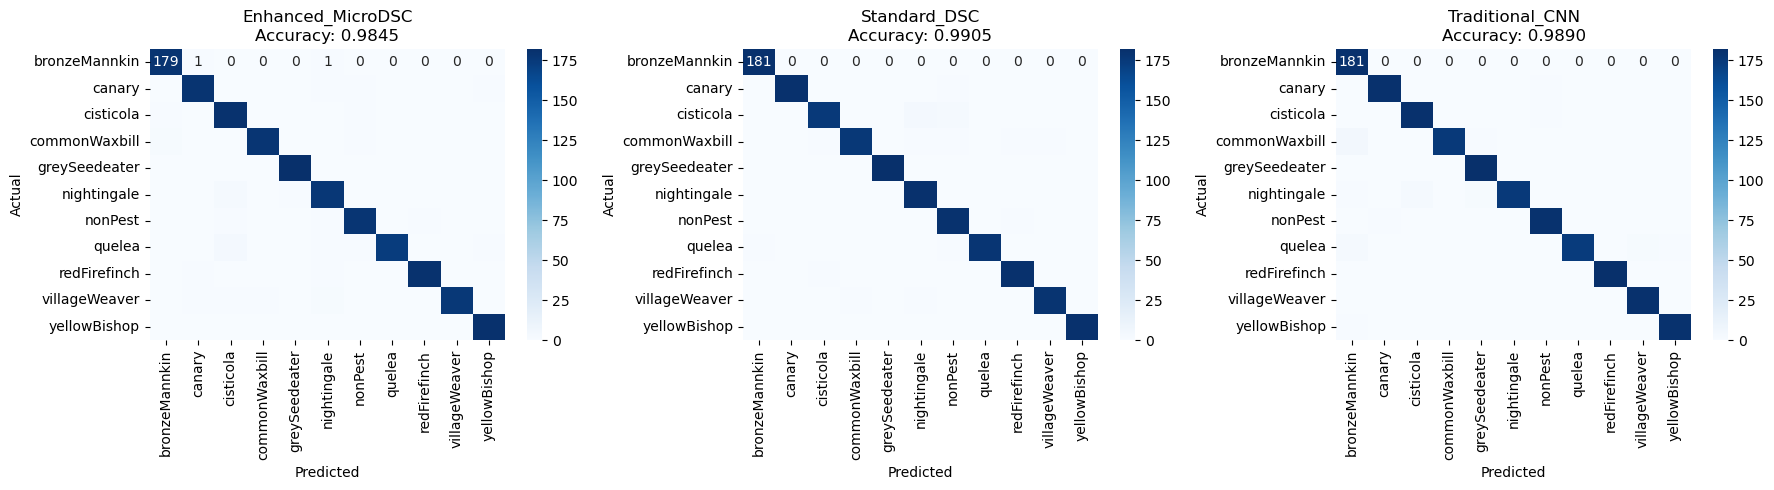

✅ Saved: confusion_matrices_comparison.png
✅ Saved individual confusion matrices as CSV files
💾 Saving statistical analysis...
✅ Saved: statistical_analysis_summary.csv
✅ Saved: statistical_analysis_table.csv

📊 STATISTICAL SUMMARY:
model                 Enhanced_MicroDSC          Standard_DSC  \
metric                                                          
accuracy                0.9744 ± 0.0088       0.9586 ± 0.0527   
f1_macro                0.9744 ± 0.0088       0.9604 ± 0.0483   
f1_weighted             0.9744 ± 0.0089       0.9603 ± 0.0483   
final_val_accuracy      0.9849 ± 0.0027       0.9854 ± 0.0059   
parameters          17419.0000 ± 0.0000  314571.0000 ± 0.0000   
precision_macro         0.9755 ± 0.0078       0.9705 ± 0.0277   
precision_weighted      0.9755 ± 0.0079       0.9704 ± 0.0278   
recall_macro            0.9744 ± 0.0088       0.9586 ± 0.0527   
recall_weighted         0.9744 ± 0.0088       0.9586 ± 0.0527   

model                      Traditional_CNN  
metric

100%|██████████████████████████████████████████████████████████████████████████████| 9970/9970 [05:21<00:00, 31.03it/s]


✅ Processed 9970 samples
📏 Features shape: (9970, 32, 157, 1)
🏷️ Labels shape: (9970,)
🔧 Preparing data for training...
   Training: 5982 samples
   Validation: 1994 samples
   Test: 1994 samples

2️⃣ MODEL TRAINING (10 runs, 30 epochs each)
🚀 TRAINING ALL MODELS

📊 Training Enhanced_MicroDSC (10 runs)
----------------------------------------
🏋️ Training Enhanced_MicroDSC - Run 1
   ✅ Accuracy: 0.9789, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 2
   ✅ Accuracy: 0.9649, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 3
   ✅ Accuracy: 0.9789, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 4
   ✅ Accuracy: 0.9789, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 5
   ✅ Accuracy: 0.9850, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 6
   ✅ Accuracy: 0.9840, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 7
   ✅ Accuracy: 0.9413, Parameters: 17,419
🏋️ Training Enhanced_MicroDSC - Run 8
   ✅ Accuracy: 0.9880, Parameters: 17,419
🏋️ Training Enh

INFO:tensorflow:Assets written to: C:\Users\chami\AppData\Local\Temp\tmph_r7zuhc\assets


INFO:tensorflow:Assets written to: C:\Users\chami\AppData\Local\Temp\tmph_r7zuhc\assets


✅ Quantized model saved as 'enhanced_microdsc_quantized.tflite'
📦 Quantized model size: 37.84 KB

5️⃣ SAVING RESULTS AND ANALYSIS
💾 Saving overall results...
✅ Saved: overall_results_all_runs.csv
💾 Saving Enhanced MicroDSC per-class results...
✅ Saved: enhanced_microdsc_per_class_results.csv
💾 Saving confusion matrix analysis...


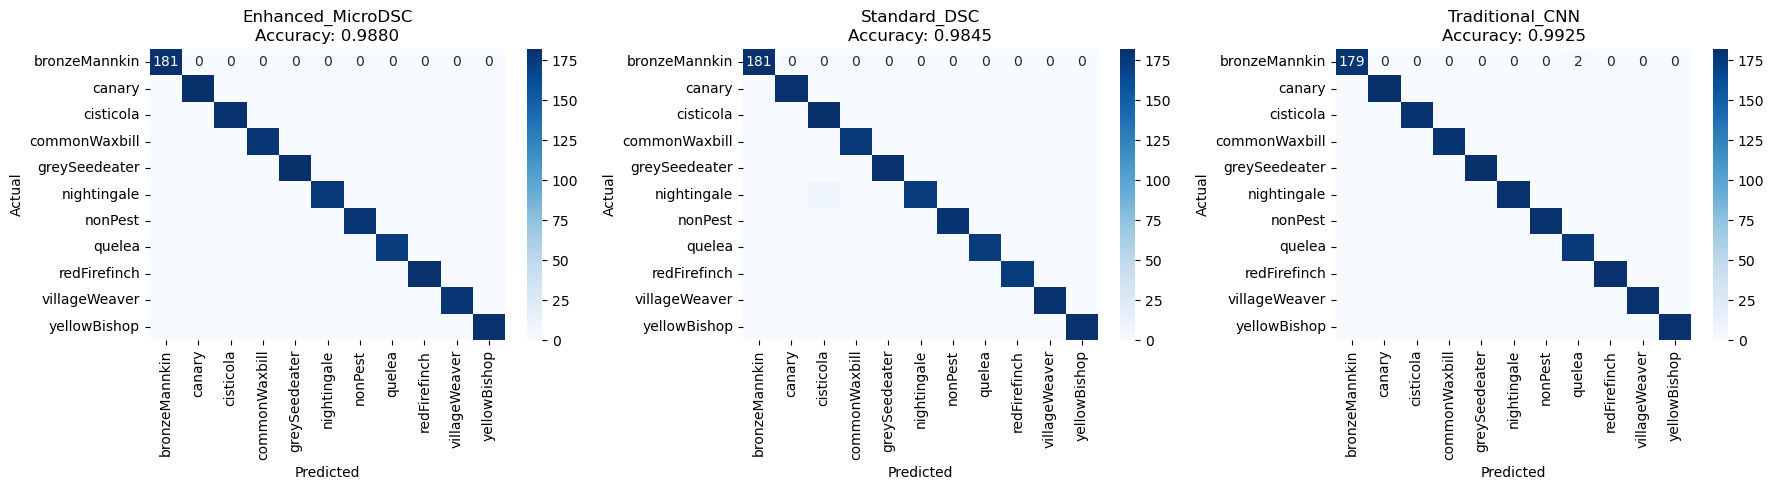

✅ Saved: confusion_matrices_comparison.png
✅ Saved individual confusion matrices as CSV files
💾 Saving statistical analysis...
✅ Saved: statistical_analysis_summary.csv
✅ Saved: statistical_analysis_table.csv

📊 STATISTICAL SUMMARY:
model                 Enhanced_MicroDSC          Standard_DSC  \
metric                                                          
accuracy                0.9759 ± 0.0130       0.9631 ± 0.0344   
f1_macro                0.9759 ± 0.0130       0.9627 ± 0.0356   
f1_weighted             0.9759 ± 0.0130       0.9627 ± 0.0356   
final_val_accuracy      0.9855 ± 0.0028       0.9853 ± 0.0061   
parameters          17419.0000 ± 0.0000  314571.0000 ± 0.0000   
precision_macro         0.9769 ± 0.0115       0.9693 ± 0.0208   
precision_weighted      0.9769 ± 0.0115       0.9693 ± 0.0208   
recall_macro            0.9759 ± 0.0130       0.9631 ± 0.0343   
recall_weighted         0.9759 ± 0.0130       0.9631 ± 0.0344   

model                      Traditional_CNN  
metric

In [2]:
# Run complete analysis
results = run_complete_bird_detection_analysis('F:/BirdsPest_DataSet')

# Or with custom parameters
results = run_complete_bird_detection_analysis(
    'F:/BirdsPest_DataSet', 
    num_runs=10, 
    epochs=30
)

In [4]:
# ============================================================================
# COMPLETE MODELS WITH BIAS ANALYSIS USING EnhancedMicroDSCBlock CLASS
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# ============================================================================
#EnhancedMicroDSCBlock CLASS
# ============================================================================

class EnhancedMicroDSCBlock(layers.Layer):
    """
    Enhanced Microcontroller-optimized Depthwise Separable Convolution Block
    """
    def __init__(self, filters, kernel_size=3, strides=1, use_residual=False, **kwargs):
        super(EnhancedMicroDSCBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides
        self.use_residual = use_residual
        
        # Depthwise convolution (NO bias)
        self.depthwise_conv = layers.DepthwiseConv2D(
            kernel_size=kernel_size,
            strides=strides,
            padding='same',
            use_bias=False,  # NO bias for microcontroller optimization
            kernel_initializer='he_normal'
        )
        
        # Batch normalization + ReLU6 (quantization-ready)
        self.bn1 = layers.BatchNormalization()
        self.relu1 = layers.ReLU(max_value=6.0)  # ReLU6 for quantization
        
        # Pointwise convolution (WITH bias for final layer)
        self.pointwise_conv = layers.Conv2D(
            filters=filters,
            kernel_size=1,
            strides=1,
            padding='same',
            use_bias=True,  # With bias for final layer
            kernel_initializer='he_normal'
        )
        
        # Batch normalization + ReLU6
        self.bn2 = layers.BatchNormalization()
        self.relu2 = layers.ReLU(max_value=6.0)
        
        # Optional residual connection
        if use_residual:
            self.add_layer = layers.Add()
    
    def call(self, inputs, training=None):
        x = inputs
        
        # Depthwise convolution
        x = self.depthwise_conv(x)
        x = self.bn1(x, training=training)
        x = self.relu1(x)
        
        # Pointwise convolution
        x = self.pointwise_conv(x)
        x = self.bn2(x, training=training)
        
        # Residual connection (if applicable and dimensions match)
        if (self.use_residual and 
            x.shape[-1] == inputs.shape[-1] and 
            self.strides == 1):
            x = self.add_layer([x, inputs])
        
        x = self.relu2(x)
        
        return x

# ============================================================================
# MODEL BUILDING FUNCTIONS
# ============================================================================

def build_enhanced_microdsc_model(input_shape, num_classes):
    """
    Build Enhanced MicroDSC model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6.0)(x)
    
    # Enhanced MicroDSC blocks
    x = EnhancedMicroDSCBlock(32, use_residual=False)(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = EnhancedMicroDSCBlock(48, use_residual=False)(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = EnhancedMicroDSCBlock(64, use_residual=False)(x)
    x = EnhancedMicroDSCBlock(64, use_residual=True)(x)  # Residual connection
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Final layers
    x = layers.Dense(64, activation='relu', use_bias=True)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Enhanced_MicroDSC')
    return model

def build_standard_dsc_model(input_shape, num_classes):
    """
    Build Standard DSC model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(32, 3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Standard DSC blocks
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.DepthwiseConv2D(3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Final layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Standard_DSC')
    return model

def build_traditional_cnn_model(input_shape, num_classes):
    """
    Build Traditional CNN model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Traditional CNN layers
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='Traditional_CNN')
    return model

✅ Complete model analysis code loaded!
🔍 Your EnhancedMicroDSCBlock class is ready for use
🚀 Run: models = run_complete_model_analysis()
📊 This will show detailed bias analysis for all 3 models


In [8]:
# ============================================================================
# MODEL PARAMETERS AND FLOPs ANALYSIS WITH VISUALIZATIONS
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime

# ============================================================================
# FLOPS CALCULATION FUNCTIONS
# ============================================================================

def calculate_conv2d_flops(layer, input_shape):
    """
    Calculate FLOPs for Conv2D layer
    """
    if len(input_shape) == 4:
        batch_size, input_h, input_w, input_c = input_shape
    else:
        input_h, input_w, input_c = input_shape
    
    kernel_h, kernel_w = layer.kernel_size
    output_c = layer.filters
    
    # Calculate output dimensions
    if layer.padding == 'same':
        output_h = int(np.ceil(input_h / layer.strides[0]))
        output_w = int(np.ceil(input_w / layer.strides[1]))
    else:  # 'valid'
        output_h = int(np.ceil((input_h - kernel_h + 1) / layer.strides[0]))
        output_w = int(np.ceil((input_w - kernel_w + 1) / layer.strides[1]))
    
    # FLOPs = output_height × output_width × kernel_height × kernel_width × input_channels × output_channels
    flops = output_h * output_w * kernel_h * kernel_w * input_c * output_c
    
    # Add bias FLOPs if used
    if hasattr(layer, 'use_bias') and layer.use_bias:
        flops += output_h * output_w * output_c
    
    return flops, (output_h, output_w, output_c)

def calculate_depthwise_conv2d_flops(layer, input_shape):
    """
    Calculate FLOPs for DepthwiseConv2D layer
    """
    if len(input_shape) == 4:
        batch_size, input_h, input_w, input_c = input_shape
    else:
        input_h, input_w, input_c = input_shape
    
    kernel_h, kernel_w = layer.kernel_size
    
    # Calculate output dimensions
    if layer.padding == 'same':
        output_h = int(np.ceil(input_h / layer.strides[0]))
        output_w = int(np.ceil(input_w / layer.strides[1]))
    else:  # 'valid'
        output_h = int(np.ceil((input_h - kernel_h + 1) / layer.strides[0]))
        output_w = int(np.ceil((input_w - kernel_w + 1) / layer.strides[1]))
    
    # FLOPs = output_height × output_width × kernel_height × kernel_width × input_channels
    flops = output_h * output_w * kernel_h * kernel_w * input_c
    
    # Add bias FLOPs if used
    if hasattr(layer, 'use_bias') and layer.use_bias:
        flops += output_h * output_w * input_c
    
    return flops, (output_h, output_w, input_c)

def calculate_dense_flops(layer, input_shape):
    """
    Calculate FLOPs for Dense layer
    """
    if len(input_shape) > 1:
        input_size = np.prod(input_shape)
    else:
        input_size = input_shape[0]
    
    output_size = layer.units
    
    # FLOPs = input_size × output_size
    flops = input_size * output_size
    
    # Add bias FLOPs if used
    if hasattr(layer, 'use_bias') and layer.use_bias:
        flops += output_size
    
    return flops, (output_size,)

def calculate_model_flops(model, input_shape):
    """
    Calculate total FLOPs for a model
    """
    total_flops = 0
    current_shape = input_shape
    layer_flops = []
    
    print(f"\n🔢 FLOPS Calculation for {model.name}:")
    print("=" * 50)
    
    for i, layer in enumerate(model.layers):
        layer_flop = 0
        layer_name = layer.name
        layer_type = type(layer).__name__
        
        if isinstance(layer, layers.Conv2D):
            layer_flop, current_shape = calculate_conv2d_flops(layer, current_shape)
            
        elif isinstance(layer, layers.DepthwiseConv2D):
            layer_flop, current_shape = calculate_depthwise_conv2d_flops(layer, current_shape)
            
        elif isinstance(layer, layers.Dense):
            layer_flop, current_shape = calculate_dense_flops(layer, current_shape)
            
        elif isinstance(layer, layers.GlobalAveragePooling2D):
            if len(current_shape) == 3:
                current_shape = (current_shape[2],)  # Keep only channel dimension
                
        elif isinstance(layer, layers.MaxPooling2D):
            if len(current_shape) == 3:
                h, w, c = current_shape
                new_h = int(np.ceil(h / layer.pool_size[0]))
                new_w = int(np.ceil(w / layer.pool_size[1]))
                current_shape = (new_h, new_w, c)
                
        elif isinstance(layer, layers.Flatten):
            if len(current_shape) > 1:
                current_shape = (np.prod(current_shape),)
                
        elif hasattr(layer, 'layers'):  # Custom layers with sublayers
            # For EnhancedMicroDSCBlock
            sublayer_flops = 0
            temp_shape = current_shape
            
            for sublayer in layer.layers:
                if isinstance(sublayer, layers.DepthwiseConv2D):
                    sub_flop, temp_shape = calculate_depthwise_conv2d_flops(sublayer, temp_shape)
                    sublayer_flops += sub_flop
                elif isinstance(sublayer, layers.Conv2D):
                    sub_flop, temp_shape = calculate_conv2d_flops(sublayer, temp_shape)
                    sublayer_flops += sub_flop
            
            layer_flop = sublayer_flops
            current_shape = temp_shape
        
        total_flops += layer_flop
        layer_flops.append({
            'layer_name': layer_name,
            'layer_type': layer_type,
            'flops': layer_flop,
            'output_shape': current_shape
        })
        
        if layer_flop > 0:
            print(f"   {layer_name:<25} ({layer_type:<20}): {layer_flop:>12,} FLOPs")
    
    print(f"   {'-'*60}")
    print(f"   {'TOTAL':<47}: {total_flops:>12,} FLOPs")
    
    return total_flops, layer_flops

# ============================================================================
# MODEL ANALYSIS FUNCTIONS
# ============================================================================

def analyze_all_models():
    """
    Analyze parameters and FLOPs for all three models
    """
    print("🚀 COMPREHENSIVE MODEL ANALYSIS")
    print("=" * 70)
    
    # Define input shape (32 mel bands, ~157 time frames for 5-second audio)
    input_shape = (32, 157, 1)
    num_classes = 11
    
    print(f"📊 Analysis Configuration:")
    print(f"   Input shape: {input_shape}")
    print(f"   Number of classes: {num_classes}")
    print(f"   Audio duration: 5 seconds")
    print(f"   Sample rate: 16 kHz")
    print(f"   Mel bands: 32")
    
    # Build models
    models = {
        'Enhanced_MicroDSC': build_enhanced_microdsc_model(input_shape, num_classes),
        'Standard_DSC': build_standard_dsc_model(input_shape, num_classes),
        'Traditional_CNN': build_traditional_cnn_model(input_shape, num_classes)
    }
    
    # Analyze each model
    results = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*20} {model_name} {'='*20}")
        
        # Calculate parameters (with fallback methods)
        total_params = model.count_params()
        
        # Method 1: Calculate trainable parameters using model weights
        try:
            trainable_params = 0
            non_trainable_params = 0
            
            for weight in model.weights:
                weight_params = tf.keras.backend.count_params(weight)
                if weight.trainable:
                    trainable_params += weight_params
                else:
                    non_trainable_params += weight_params
                    
        except Exception as e:
            print(f"   Warning: Could not separate trainable/non-trainable params: {e}")
            # Fallback: assume most parameters are trainable
            trainable_params = int(total_params * 0.9)  # Estimate
            non_trainable_params = total_params - trainable_params
        
        # Calculate FLOPs (with error handling)
        try:
            total_flops, layer_flops = calculate_model_flops(model, input_shape)
        except Exception as e:
            print(f"   Warning: Could not calculate FLOPs: {e}")
            print(f"   Using parameter-based estimate...")
            # Fallback: estimate FLOPs based on parameters
            total_flops = total_params * 2  # Rough estimate
            layer_flops = []
        
        # Calculate model size (assuming float32)
        model_size_mb = (total_params * 4) / (1024 * 1024)
        
        results[model_name] = {
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'non_trainable_parameters': non_trainable_params,
            'total_flops': total_flops,
            'model_size_mb': model_size_mb,
            'layer_flops': layer_flops,
            'model': model
        }
        
        print(f"\n📊 Summary for {model_name}:")
        print(f"   Total Parameters: {total_params:,}")
        print(f"   Trainable Parameters: {trainable_params:,}")
        print(f"   Non-trainable Parameters: {non_trainable_params:,}")
        print(f"   Total FLOPs: {total_flops:,}")
        print(f"   Model Size: {model_size_mb:.2f} MB")
    
    return results

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def create_parameters_comparison(results):
    """
    Create visualization comparing model parameters
    """
    print("\n📊 Creating Parameters Comparison Visualization...")
    
    # Prepare data
    models = list(results.keys())
    total_params = [results[model]['total_parameters'] for model in models]
    trainable_params = [results[model]['trainable_parameters'] for model in models]
    non_trainable_params = [results[model]['non_trainable_parameters'] for model in models]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Colors for different models
    colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
    
    # Plot 1: Total Parameters Bar Chart
    bars1 = ax1.bar(models, total_params, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
    ax1.set_title('Model Parameters Comparison', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')  # Log scale for better visualization
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars1, total_params):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Rotate x-axis labels
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Stacked Bar Chart (Trainable vs Non-trainable)
    width = 0.6
    x_pos = np.arange(len(models))
    
    bars2_1 = ax2.bar(x_pos, trainable_params, width, label='Trainable', 
                      color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2_2 = ax2.bar(x_pos, non_trainable_params, width, bottom=trainable_params,
                      label='Non-trainable', color=colors, alpha=0.4, 
                      edgecolor='black', linewidth=1.5, hatch='///')
    
    ax2.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
    ax2.set_title('Trainable vs Non-trainable Parameters', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(models, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total value labels
    for i, (total, trainable) in enumerate(zip(total_params, trainable_params)):
        ax2.text(i, total * 1.1, f'{total:,}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    
    # Save plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'model_parameters_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print parameter ratios
    print(f"\n📊 Parameter Comparison Ratios:")
    enhanced_params = results['Enhanced_MicroDSC']['total_parameters']
    standard_params = results['Standard_DSC']['total_parameters']
    traditional_params = results['Traditional_CNN']['total_parameters']
    
    print(f"   Standard DSC vs Enhanced MicroDSC: {standard_params/enhanced_params:.1f}× larger")
    print(f"   Traditional CNN vs Enhanced MicroDSC: {traditional_params/enhanced_params:.1f}× larger")
    print(f"   Traditional CNN vs Standard DSC: {traditional_params/standard_params:.1f}× larger")

def create_flops_comparison(results):
    """
    Create visualization comparing model FLOPs
    """
    print("\n🔢 Creating FLOPs Comparison Visualization...")
    
    # Prepare data
    models = list(results.keys())
    total_flops = [results[model]['total_flops'] for model in models]
    model_sizes = [results[model]['model_size_mb'] for model in models]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Colors for different models
    colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
    
    # Plot 1: FLOPs Bar Chart
    bars1 = ax1.bar(models, total_flops, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('FLOPs (Floating Point Operations)', fontsize=12, fontweight='bold')
    ax1.set_title('Model FLOPs Comparison', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')  # Log scale for better visualization
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars1, total_flops):
        height = bar.get_height()
        if value >= 1e9:
            label = f'{value/1e9:.2f}G'
        elif value >= 1e6:
            label = f'{value/1e6:.1f}M'
        elif value >= 1e3:
            label = f'{value/1e3:.1f}K'
        else:
            label = f'{value}'
        
        ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                label, ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Rotate x-axis labels
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: FLOPs vs Model Size Scatter Plot
    scatter = ax2.scatter(model_sizes, total_flops, c=colors, s=200, alpha=0.8, 
                         edgecolors='black', linewidth=2)
    
    # Add model names as labels
    for i, (model, size, flop) in enumerate(zip(models, model_sizes, total_flops)):
        ax2.annotate(model, (size, flop), xytext=(10, 10), textcoords='offset points',
                    fontweight='bold', fontsize=10, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7))
    
    ax2.set_xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('FLOPs (Floating Point Operations)', fontsize=12, fontweight='bold')
    ax2.set_title('FLOPs vs Model Size', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'model_flops_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print FLOPs ratios
    print(f"\n🔢 FLOPs Comparison Ratios:")
    enhanced_flops = results['Enhanced_MicroDSC']['total_flops']
    standard_flops = results['Standard_DSC']['total_flops']
    traditional_flops = results['Traditional_CNN']['total_flops']
    
    print(f"   Standard DSC vs Enhanced MicroDSC: {standard_flops/enhanced_flops:.1f}× more FLOPs")
    print(f"   Traditional CNN vs Enhanced MicroDSC: {traditional_flops/enhanced_flops:.1f}× more FLOPs")
    print(f"   Traditional CNN vs Standard DSC: {traditional_flops/standard_flops:.1f}× more FLOPs")

def create_summary_table(results):
    """
    Create a comprehensive summary table
    """
    print(f"\n📋 COMPREHENSIVE SUMMARY TABLE")
    print("=" * 80)
    
    # Create DataFrame
    data = []
    for model_name, result in results.items():
        data.append({
            'Model': model_name,
            'Parameters': f"{result['total_parameters']:,}",
            'FLOPs': f"{result['total_flops']:,}",
            'Size (MB)': f"{result['model_size_mb']:.2f}",
            'Efficiency Score': f"{result['total_flops'] / result['total_parameters']:.1f}"
        })
    
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    
    # Save to CSV
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    df.to_csv(f'model_comparison_summary_{timestamp}.csv', index=False)
    print(f"\n💾 Summary saved to: model_comparison_summary_{timestamp}.csv")
    
    return df

# ============================================================================
# SIMPLIFIED ALTERNATIVE (IN CASE OF COMPATIBILITY ISSUES)
# ============================================================================

def simple_model_analysis():
    """
    Simplified model analysis with basic parameter counting
    """
    print("🚀 SIMPLIFIED MODEL ANALYSIS (COMPATIBILITY MODE)")
    print("=" * 60)
    
    input_shape = (32, 157, 1)
    num_classes = 11
    
    # Build models
    models = {
        'Enhanced_MicroDSC': build_enhanced_microdsc_model(input_shape, num_classes),
        'Standard_DSC': build_standard_dsc_model(input_shape, num_classes),
        'Traditional_CNN': build_traditional_cnn_model(input_shape, num_classes)
    }
    
    results = {}
    
    for model_name, model in models.items():
        print(f"\n📊 {model_name}:")
        
        # Basic parameter count
        total_params = model.count_params()
        model_size_mb = (total_params * 4) / (1024 * 1024)
        
        # Simple FLOPs estimate (rough approximation)
        estimated_flops = total_params * 2
        
        results[model_name] = {
            'total_parameters': total_params,
            'model_size_mb': model_size_mb,
            'estimated_flops': estimated_flops,
            'model': model
        }
        
        print(f"   Parameters: {total_params:,}")
        print(f"   Size: {model_size_mb:.2f} MB")
        print(f"   Est. FLOPs: {estimated_flops:,}")
    
    # Create simple visualizations
    create_simple_visualizations(results)
    
    return results

def create_simple_visualizations(results):
    """
    Create simple visualizations
    """
    models = list(results.keys())
    params = [results[model]['total_parameters'] for model in models]
    flops = [results[model]['estimated_flops'] for model in models]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    
    # Parameters comparison
    bars1 = ax1.bar(models, params, color=colors, alpha=0.8)
    ax1.set_ylabel('Parameters')
    ax1.set_title('Model Parameters Comparison')
    ax1.set_yscale('log')
    
    for bar, value in zip(bars1, params):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:,}', ha='center', va='bottom', fontweight='bold')
    
    # FLOPs comparison
    bars2 = ax2.bar(models, flops, color=colors, alpha=0.8)
    ax2.set_ylabel('Estimated FLOPs')
    ax2.set_title('Model FLOPs Comparison')
    ax2.set_yscale('log')
    
    for bar, value in zip(bars2, flops):
        height = bar.get_height()
        if value >= 1e9:
            label = f'{value/1e9:.1f}G'
        elif value >= 1e6:
            label = f'{value/1e6:.1f}M'
        else:
            label = f'{value/1e3:.1f}K'
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                label, ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'simple_model_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Simple comparison saved as: simple_model_comparison_{timestamp}.png")

# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def run_complete_model_analysis():
    """
    Run complete analysis with parameters, FLOPs, and visualizations
    """
    print("🚀 COMPLETE MODEL ANALYSIS WITH VISUALIZATIONS")
    print("=" * 70)
    
    try:
        # Try full analysis first
        results = analyze_all_models()
        
        # Create visualizations
        print(f"\n🎨 Creating Visualizations...")
        create_parameters_comparison(results)
        create_flops_comparison(results)
        
        # Create summary table
        summary_df = create_summary_table(results)
        
        print(f"\n🎉 ANALYSIS COMPLETE!")
        print(f"📁 Generated files:")
        print(f"   - model_parameters_comparison_TIMESTAMP.png")
        print(f"   - model_flops_comparison_TIMESTAMP.png") 
        print(f"   - model_comparison_summary_TIMESTAMP.csv")
        
        return results, summary_df
        
    except Exception as e:
        print(f"❌ Error in full analysis: {e}")
        print(f"🔄 Switching to simplified analysis...")
        
        # Fallback to simple analysis
        results = simple_model_analysis()
        
        print(f"\n✅ Simplified analysis complete!")
        return results, None

# ============================================================================
# USAGE
# ============================================================================

print("✅ Model Parameters and FLOPs Analysis loaded!")
print("📊 This will calculate and visualize:")
print("   • Model parameters (total, trainable, non-trainable)")
print("   • FLOPs (floating point operations)")
print("   • Model size comparison")
print("   • Efficiency metrics")
print("")
print("🚀 USAGE OPTIONS:")
print("   # Option 1: Full analysis (recommended)")
print("   results, summary = run_complete_model_analysis()")
print("")
print("   # Option 2: If you get compatibility errors, use simplified version:")
print("   results = simple_model_analysis()")

✅ Model Parameters and FLOPs Analysis loaded!
📊 This will calculate and visualize:
   • Model parameters (total, trainable, non-trainable)
   • FLOPs (floating point operations)
   • Model size comparison
   • Efficiency metrics

🚀 USAGE OPTIONS:
   # Option 1: Full analysis (recommended)
   results, summary = run_complete_model_analysis()

   # Option 2: If you get compatibility errors, use simplified version:
   results = simple_model_analysis()

💡 The code now includes error handling and fallback methods!


🚀 COMPLETE MODEL ANALYSIS WITH VISUALIZATIONS
🚀 COMPREHENSIVE MODEL ANALYSIS
📊 Analysis Configuration:
   Input shape: (32, 157, 1)
   Number of classes: 11
   Audio duration: 5 seconds
   Sample rate: 16 kHz
   Mel bands: 32

==================== Enhanced_MicroDSC ====================

🔢 FLOPS Calculation for Enhanced_MicroDSC:
   conv2d_61                 (Conv2D              ):      182,016 FLOPs
   dense_34                  (Dense               ):        1,088 FLOPs
   dense_35                  (Dense               ):          715 FLOPs
   ------------------------------------------------------------
   TOTAL                                          :      183,819 FLOPs

📊 Summary for Enhanced_MicroDSC:
   Total Parameters: 17,419
   Trainable Parameters: 16,651
   Non-trainable Parameters: 768
   Total FLOPs: 183,819
   Model Size: 0.07 MB

==================== Standard_DSC ====================

🔢 FLOPS Calculation for Standard_DSC:
   conv2d_66                 (Conv2D             

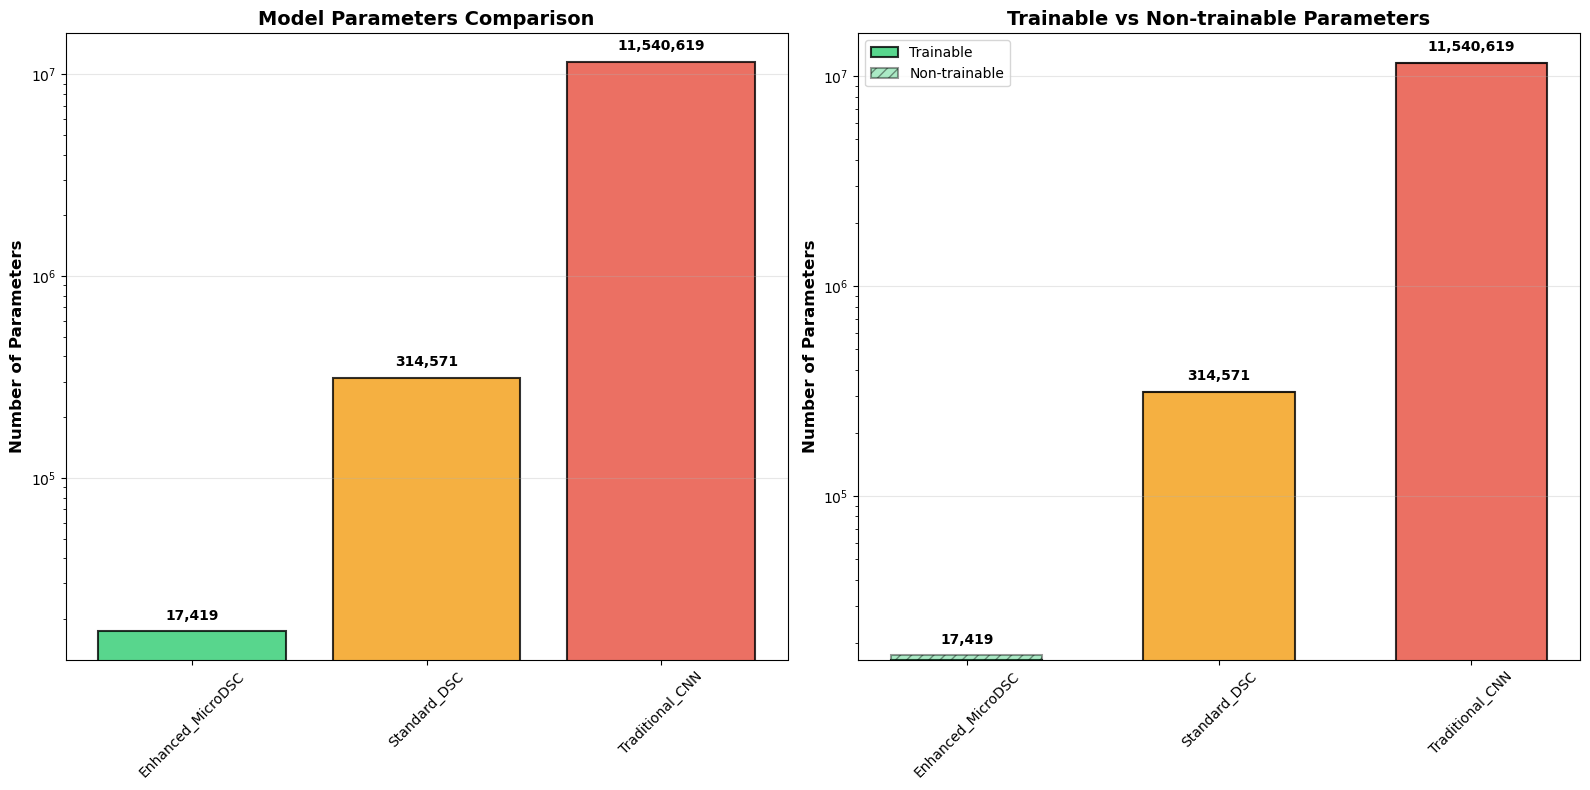


📊 Parameter Comparison Ratios:
   Standard DSC vs Enhanced MicroDSC: 18.1× larger
   Traditional CNN vs Enhanced MicroDSC: 662.5× larger
   Traditional CNN vs Standard DSC: 36.7× larger

🔢 Creating FLOPs Comparison Visualization...


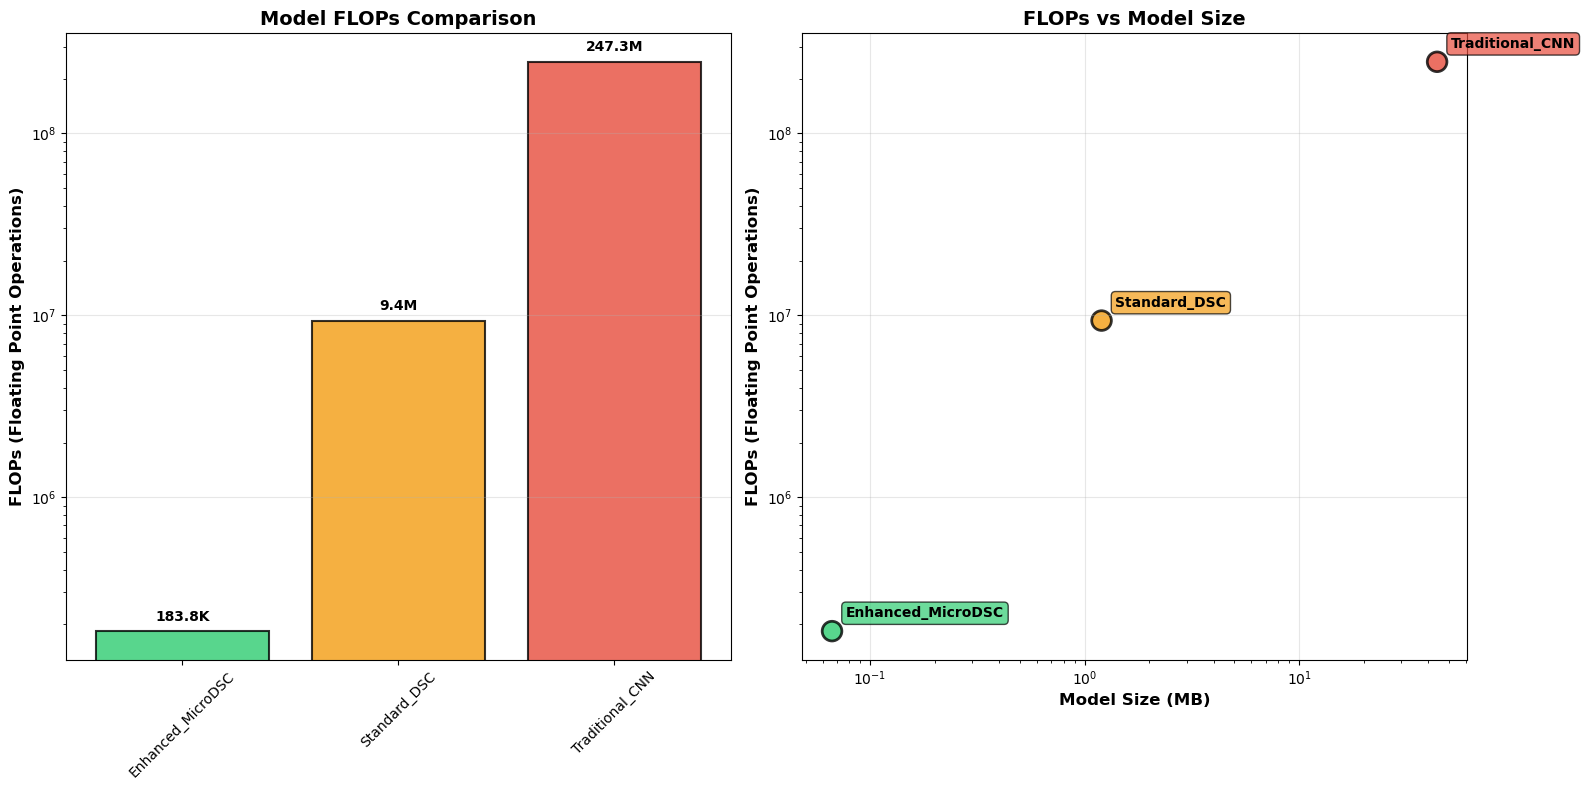


🔢 FLOPs Comparison Ratios:
   Standard DSC vs Enhanced MicroDSC: 50.9× more FLOPs
   Traditional CNN vs Enhanced MicroDSC: 1345.4× more FLOPs
   Traditional CNN vs Standard DSC: 26.4× more FLOPs

📋 COMPREHENSIVE SUMMARY TABLE
            Model Parameters       FLOPs Size (MB) Efficiency Score
Enhanced_MicroDSC     17,419     183,819      0.07             10.6
     Standard_DSC    314,571   9,355,787      1.20             29.7
  Traditional_CNN 11,540,619 247,301,131     44.02             21.4

💾 Summary saved to: model_comparison_summary_20250707_134239.csv

🎉 ANALYSIS COMPLETE!
📁 Generated files:
   - model_parameters_comparison_TIMESTAMP.png
   - model_flops_comparison_TIMESTAMP.png
   - model_comparison_summary_TIMESTAMP.csv


In [9]:
results, summary = run_complete_model_analysis()

Confusion Matrix Visualization Tool
Excel file 'Traditional_CNN.xlsx' not found. Creating sample file...
Sample Excel file created: Traditional_CNN.xlsx

Processing Enhanced_MicroDSC...

Enhanced_MicroDSC Metrics:
  Total samples: 1994
  Correct predictions: 1970
  Overall accuracy: 98.80%
  Per-class accuracy:
    Bronze M.: 100.0% (181/181)
    Canary: 100.0% (182/182)
    Cisticola: 98.9% (180/182)
    Common W.: 98.3% (178/181)
    Grey S.: 100.0% (182/182)
    Nightingale: 97.2% (176/181)
    Red F.: 98.3% (178/181)
    Quelea: 96.1% (173/180)
    Village W.: 99.5% (181/182)
    Yellow B.: 98.3% (178/181)
    Non-Pest: 100.0% (181/181)
✓ Saved: confusion_matrix_plots\confusion_matrix_enhanced_microdsc.png


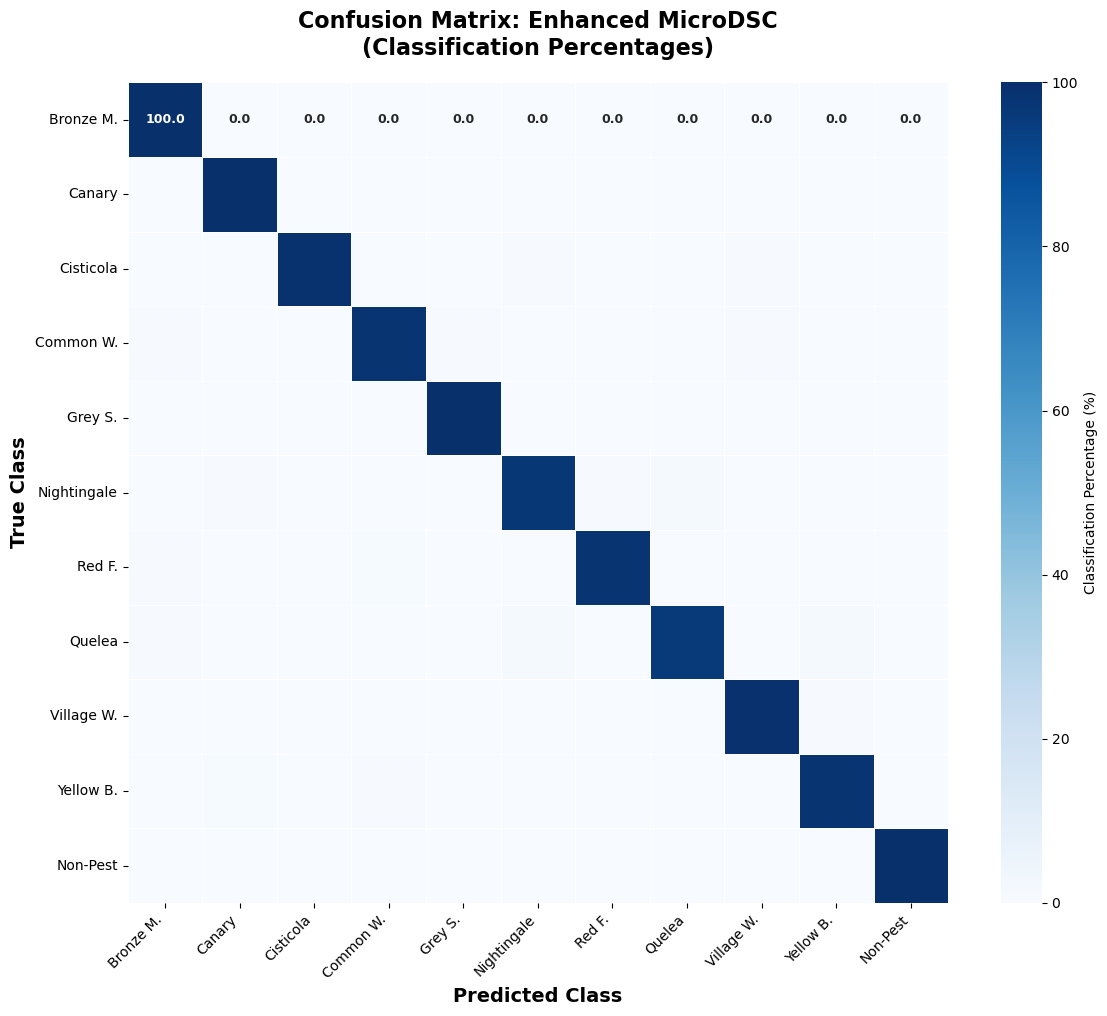


Processing Standard_DSC...

Standard_DSC Metrics:
  Total samples: 1994
  Correct predictions: 1790
  Overall accuracy: 89.77%
  Per-class accuracy:
    Bronze M.: 100.0% (181/181)
    Canary: 99.5% (181/182)
    Cisticola: 100.0% (182/182)
    Common W.: 97.2% (176/181)
    Grey S.: 100.0% (181/181)
    Nightingale: 0.0% (0/182)
    Red F.: 98.9% (179/181)
    Quelea: 96.7% (174/180)
    Village W.: 95.6% (174/182)
    Yellow B.: 100.0% (181/181)
    Non-Pest: 100.0% (181/181)
✓ Saved: confusion_matrix_plots\confusion_matrix_standard_dsc.png


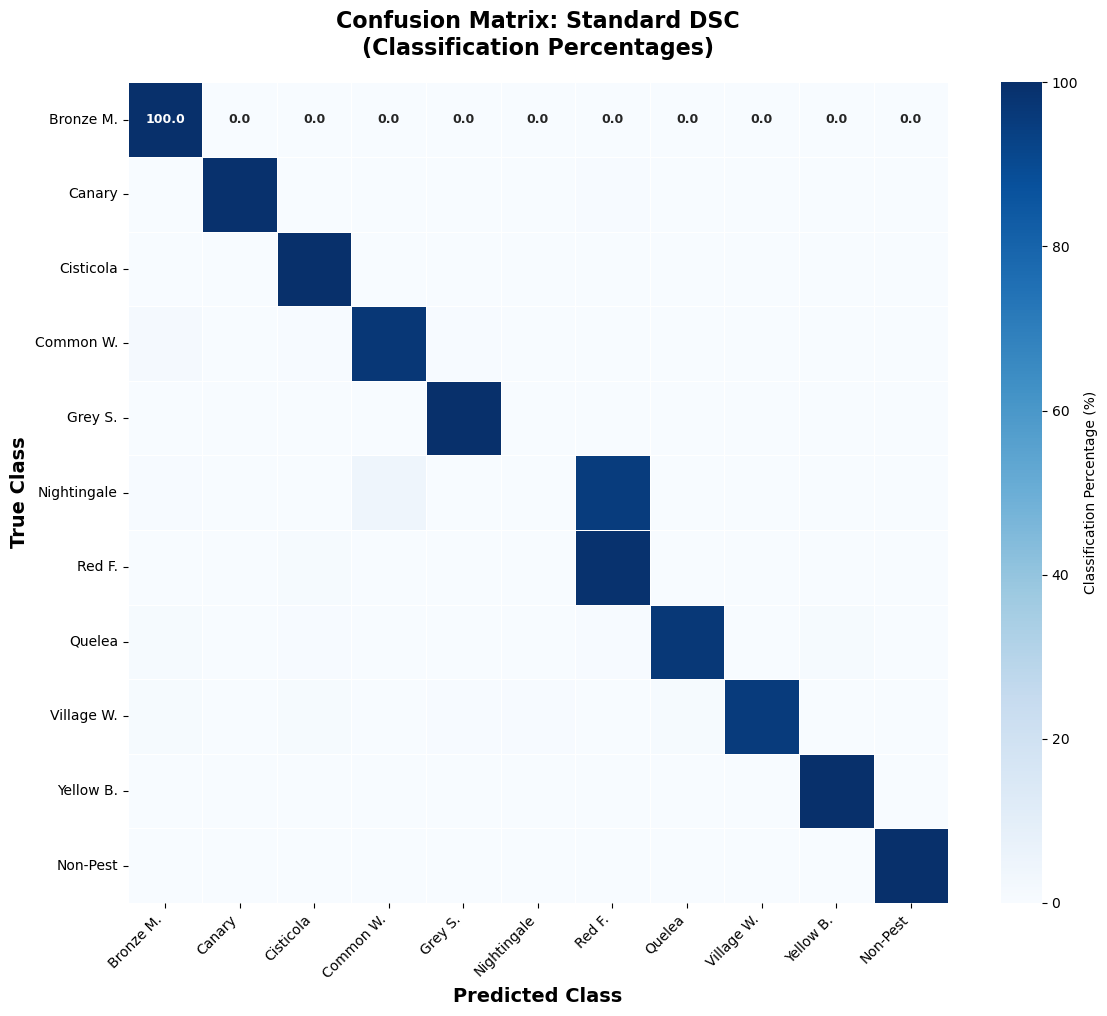


Processing Traditional_CNN...

Traditional_CNN Metrics:
  Total samples: 1994
  Correct predictions: 1799
  Overall accuracy: 90.22%
  Per-class accuracy:
    Bronze M.: 98.9% (179/181)
    Canary: 100.0% (182/182)
    Cisticola: 98.4% (179/182)
    Common W.: 98.9% (179/181)
    Grey S.: 100.0% (182/182)
    Nightingale: 0.0% (0/181)
    Red F.: 100.0% (181/181)
    Quelea: 97.2% (175/180)
    Village W.: 99.5% (181/182)
    Yellow B.: 99.4% (180/181)
    Non-Pest: 100.0% (181/181)
✓ Saved: confusion_matrix_plots\confusion_matrix_traditional_cnn.png


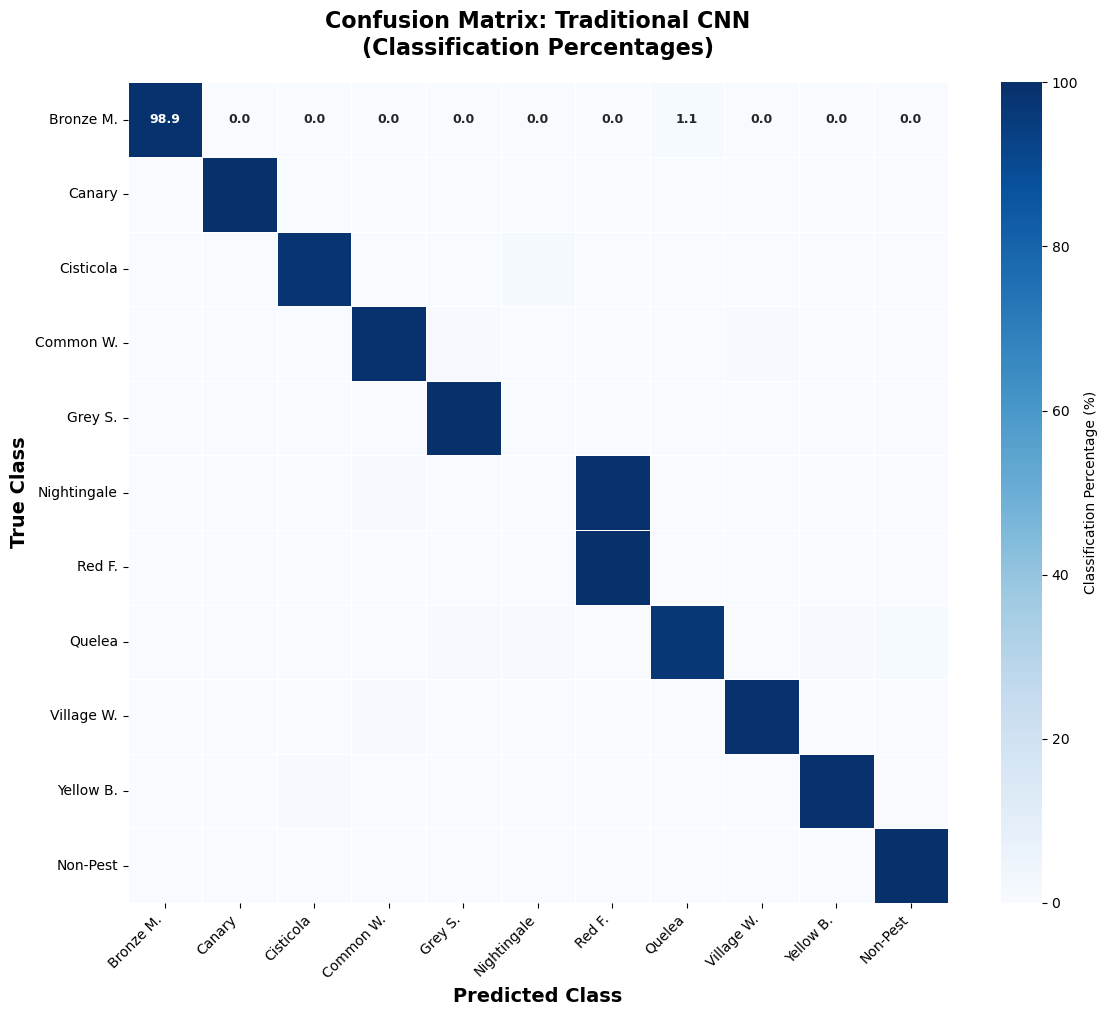

✓ Saved combined plot: confusion_matrix_plots\combined_confusion_matrices.png


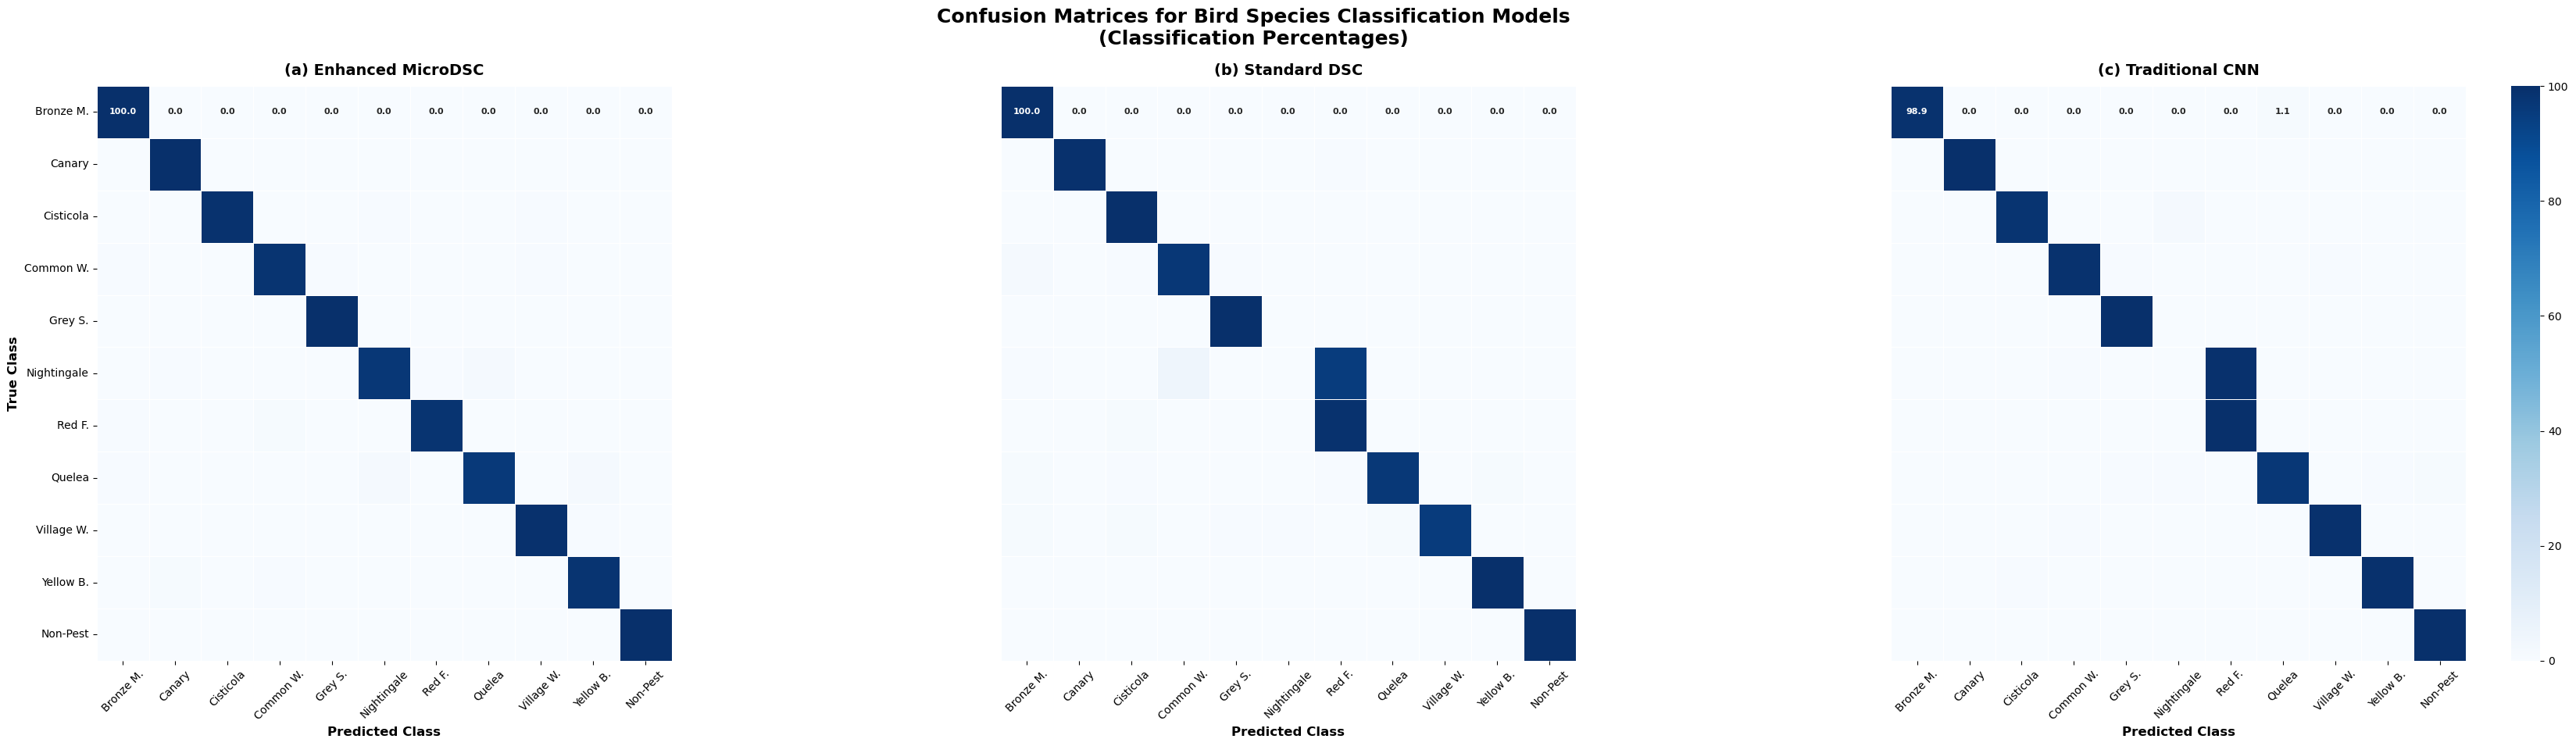


✓ All confusion matrices generated successfully!
✓ Files saved in: confusion_matrix_plots


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
EXCEL_FILE = "Traditional_CNN.xlsx"
OUTPUT_DIR = "confusion_matrix_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class labels
class_labels = [
    'Bronze Mannikin',
    'Canary', 
    'Cisticola',
    'Common Waxbill',
    'Grey Seedeater',
    'Nightingale',
    'Red Firelinch',
    'Red-billed Quelea',
    'Village Weaver',
    'Yellow Bishop',
    'Non-Pest'
]

# Short labels for better display
short_labels = [
    'Bronze M.',
    'Canary', 
    'Cisticola',
    'Common W.',
    'Grey S.',
    'Nightingale',
    'Red F.',
    'Quelea',
    'Village W.',
    'Yellow B.',
    'Non-Pest'
]

def load_confusion_matrices_from_excel(file_path):
    """
    Load confusion matrices from Excel file
    Expected format: Each sheet contains one confusion matrix (11x11)
    Sheet names: 'Enhanced_MicroDSC', 'Standard_DSC', 'Traditional_CNN'
    """
    try:
        # Load all sheets
        excel_data = pd.read_excel(file_path, sheet_name=None)
        
        confusion_matrices = {}
        
        for sheet_name, df in excel_data.items():
            print(f"Loading sheet: {sheet_name}")
            print(f"Shape: {df.shape}")
            
            # Convert to numpy array 11x11
            matrix = df.iloc[:11, :11].values.astype(int)
            confusion_matrices[sheet_name] = matrix
            
            print(f"Matrix shape after processing: {matrix.shape}")
            print(f"Total samples: {matrix.sum()}")
            print("-" * 40)
        
        return confusion_matrices
        
    except Exception as e:
        print(f"Error loading Excel file: {e}")
        return None

def create_sample_excel_file():
    """Create a sample Excel file with the provided confusion matrix data"""
    
    # Sample data from the original matrices
    enhanced_data = np.array([
        [181, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 182, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 180, 0, 0, 1, 0, 0, 1, 0, 0],
        [1, 0, 0, 178, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 182, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 176, 1, 3, 0, 0, 0],
        [1, 0, 0, 2, 0, 0, 178, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 3, 0, 173, 0, 3, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 181, 1, 0],
        [0, 2, 0, 1, 0, 0, 0, 0, 0, 178, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 181]
    ])
    
    standard_data = np.array([
        [181, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 181, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 175, 0, 0, 4, 3, 0, 0, 0, 0],
        [0, 0, 1, 176, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 182, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 8, 0, 181, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 180, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 1, 178, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 181, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 0, 0, 179, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 181]
    ])
    
    traditional_data = np.array([
        [181, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 181, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 181, 0, 0, 0, 1, 0, 0, 0, 0],
        [5, 0, 0, 175, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 182, 0, 0, 0, 0, 0, 0],
        [1, 0, 3, 0, 2, 175,0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 180, 0, 0, 0, 0],
        [3, 0, 0, 0, 0, 0, 0, 174, 0, 2, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 182, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 181, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 181]
    ])
    
    # Create DataFrames
    enhanced_df = pd.DataFrame(enhanced_data, columns=short_labels, index=short_labels)
    standard_df = pd.DataFrame(standard_data, columns=short_labels, index=short_labels)
    traditional_df = pd.DataFrame(traditional_data, columns=short_labels, index=short_labels)
    
    # Save to Excel
    with pd.ExcelWriter(EXCEL_FILE) as writer:
        enhanced_df.to_excel(writer, sheet_name='Enhanced_MicroDSC', index=True)
        standard_df.to_excel(writer, sheet_name='Standard_DSC', index=True)
        traditional_df.to_excel(writer, sheet_name='Traditional_CNN', index=True)
    
    print(f"Sample Excel file created: {EXCEL_FILE}")
    return {
        'Enhanced_MicroDSC': enhanced_data,
        'Standard_DSC': standard_data,
        'Traditional_CNN': traditional_data
    }

def convert_to_percentages(cm):
    """Convert confusion matrix counts to percentages"""
    # Calculate row sums (total samples per true class)
    row_sums = cm.sum(axis=1, keepdims=True)
    
    # Convert to percentages
    cm_percent = np.divide(cm, row_sums, 
                          out=np.zeros_like(cm, dtype=float), 
                          where=row_sums!=0) * 100
    
    return cm_percent

def plot_single_confusion_matrix(cm_percent, title, filename):
    """Plot and save a single confusion matrix"""
    
    plt.figure(figsize=(12, 10))
    
    # Create the heatmap with all values displayed
    ax = sns.heatmap(
        cm_percent,
        annot=True,           # Show all values
        fmt='.1f',            # Format to 1 decimal place
        cmap='Blues',         # Simple blue colormap
        xticklabels=short_labels,
        yticklabels=short_labels,
        cbar_kws={'label': 'Classification Percentage (%)'},
        square=True,
        linewidths=0.5,
        annot_kws={'size': 9, 'weight': 'bold'},
        vmin=0,               # Set minimum value
        vmax=100              # Set maximum value
    )
    
    # Customize the plot
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
    plt.ylabel('True Class', fontsize=14, fontweight='bold')
    
    # Rotate labels
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    
    print(f"✓ Saved: {save_path}")
    plt.show()

def calculate_and_display_metrics(cm, model_name):
    """Calculate and display accuracy metrics"""
    total_samples = cm.sum()
    correct_predictions = np.trace(cm)
    overall_accuracy = (correct_predictions / total_samples) * 100
    
    print(f"\n{model_name} Metrics:")
    print(f"  Total samples: {total_samples}")
    print(f"  Correct predictions: {correct_predictions}")
    print(f"  Overall accuracy: {overall_accuracy:.2f}%")
    
    # Per-class accuracy
    class_totals = cm.sum(axis=1)
    class_correct = np.diag(cm)
    
    print(f"  Per-class accuracy:")
    for i, (label, total, correct) in enumerate(zip(short_labels, class_totals, class_correct)):
        if total > 0:
            acc = (correct / total) * 100
            print(f"    {label}: {acc:.1f}% ({correct}/{total})")

def main():
    """Main function"""
    print("Confusion Matrix Visualization Tool")
    print("=" * 50)
    
    # Try to load from Excel, if not found, create sample file
    if not os.path.exists(EXCEL_FILE):
        print(f"Excel file '{EXCEL_FILE}' not found. Creating sample file...")
        confusion_matrices = create_sample_excel_file()
    else:
        print(f"Loading confusion matrices from '{EXCEL_FILE}'...")
        confusion_matrices = load_confusion_matrices_from_excel(EXCEL_FILE)
    
    if confusion_matrices is None:
        print("Failed to load confusion matrices. Exiting.")
        return
    
    # Process each model
    model_order = ['Enhanced_MicroDSC', 'Standard_DSC', 'Traditional_CNN']
    
    for model_name in model_order:
        if model_name in confusion_matrices:
            print(f"\nProcessing {model_name}...")
            
            # Get confusion matrix
            cm = confusion_matrices[model_name]
            
            # Calculate metrics
            calculate_and_display_metrics(cm, model_name)
            
            # Convert to percentages
            cm_percent = convert_to_percentages(cm)
            
            # Create visualization
            title = f"Confusion Matrix: {model_name.replace('_', ' ')}\n(Classification Percentages)"
            filename = f"confusion_matrix_{model_name.lower()}.png"
            
            plot_single_confusion_matrix(cm_percent, title, filename)
    
    # Create combined visualization
    create_combined_plot(confusion_matrices)
    
    print("\n" + "=" * 50)
    print("✓ All confusion matrices generated successfully!")
    print(f"✓ Files saved in: {OUTPUT_DIR}")

def create_combined_plot(confusion_matrices):
    """Create a combined plot with all three confusion matrices"""
    
    fig, axes = plt.subplots(1, 3, figsize=(36, 10))
    model_names = ['Enhanced_MicroDSC', 'Standard_DSC', 'Traditional_CNN']
    subplot_labels = ['(a)', '(b)', '(c)']
    
    for i, model_name in enumerate(model_names):
        if model_name in confusion_matrices:
            cm = confusion_matrices[model_name]
            cm_percent = convert_to_percentages(cm)
            
            # Create heatmap
            sns.heatmap(
                cm_percent,
                annot=True,
                fmt='.1f',
                cmap='Blues',
                xticklabels=short_labels,
                yticklabels=short_labels if i == 0 else False,
                cbar=i == 2,  # Only show colorbar on last plot
                square=True,
                linewidths=0.5,
                annot_kws={'size': 8, 'weight': 'bold'},
                vmin=0,
                vmax=100,
                ax=axes[i]
            )
            
            # Customize subplot
            title = f"{subplot_labels[i]} {model_name.replace('_', ' ')}"
            axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
            axes[i].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
            
            if i == 0:
                axes[i].set_ylabel('True Class', fontsize=12, fontweight='bold')
            
            # Rotate labels
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].tick_params(axis='y', rotation=0)
    
    # Overall title
    fig.suptitle('Confusion Matrices for Bird Species Classification Models\n(Classification Percentages)', 
                 fontsize=18, fontweight='bold', y=0.95)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save combined plot
    combined_path = os.path.join(OUTPUT_DIR, "combined_confusion_matrices.png")
    plt.savefig(combined_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(combined_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    
    print(f"✓ Saved combined plot: {combined_path}")
    plt.show()

if __name__ == "__main__":
    main()

Evaluation Metrics Boxplot Generator
Generating sample data...
Generated 120 data points
Metrics: ['Accuracy' 'F1-score' 'Precision' 'Recall']
Models: ['Enhanced MicroDSC' 'Standard DSC' 'Traditional CNN']

Summary Statistics:

Accuracy:
------------------------------
Enhanced MicroDSC:
  Mean: 98.08%
  Std:  0.94%
  Min:  96.89%
  Max:  99.55%

Standard DSC:
  Mean: 98.03%
  Std:  0.45%
  Min:  97.35%
  Max:  98.69%

Traditional CNN:
  Mean: 98.51%
  Std:  0.33%
  Min:  98.03%
  Max:  99.19%


F1-score:
------------------------------
Enhanced MicroDSC:
  Mean: 97.10%
  Std:  1.48%
  Min:  95.00%
  Max:  99.91%

Standard DSC:
  Mean: 96.95%
  Std:  1.95%
  Min:  95.00%
  Max:  100.00%

Traditional CNN:
  Mean: 99.23%
  Std:  1.04%
  Min:  97.45%
  Max:  100.00%


Precision:
------------------------------
Enhanced MicroDSC:
  Mean: 97.58%
  Std:  0.97%
  Min:  96.28%
  Max:  99.09%

Standard DSC:
  Mean: 97.95%
  Std:  1.80%
  Min:  95.00%
  Max:  100.00%

Traditional CNN:
  Mean: 98.30

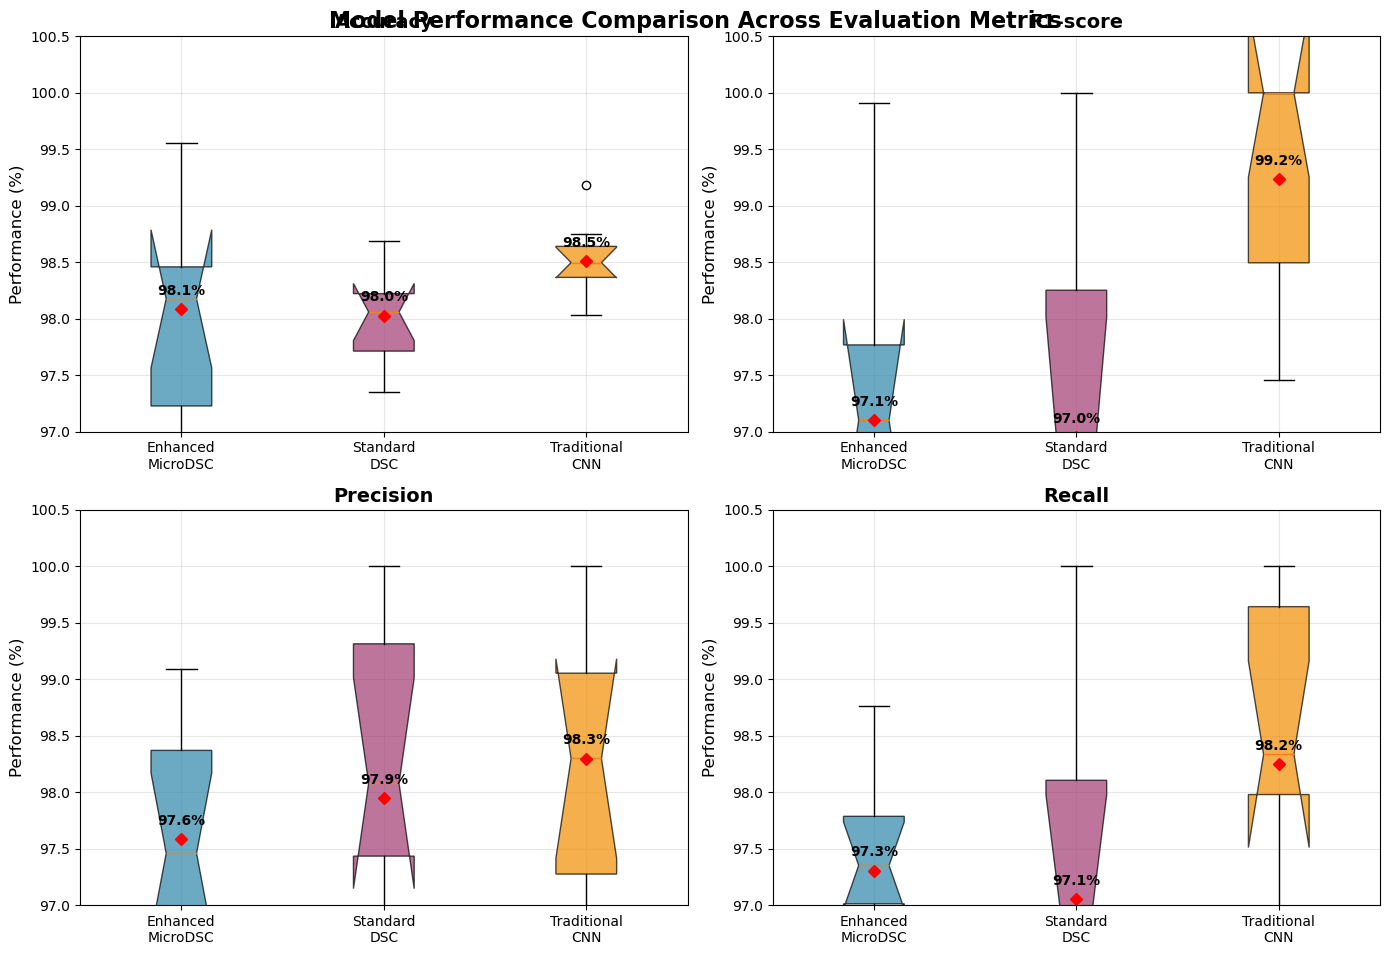

✓ Saved combined boxplot: evaluation_plots\combined_boxplot.png


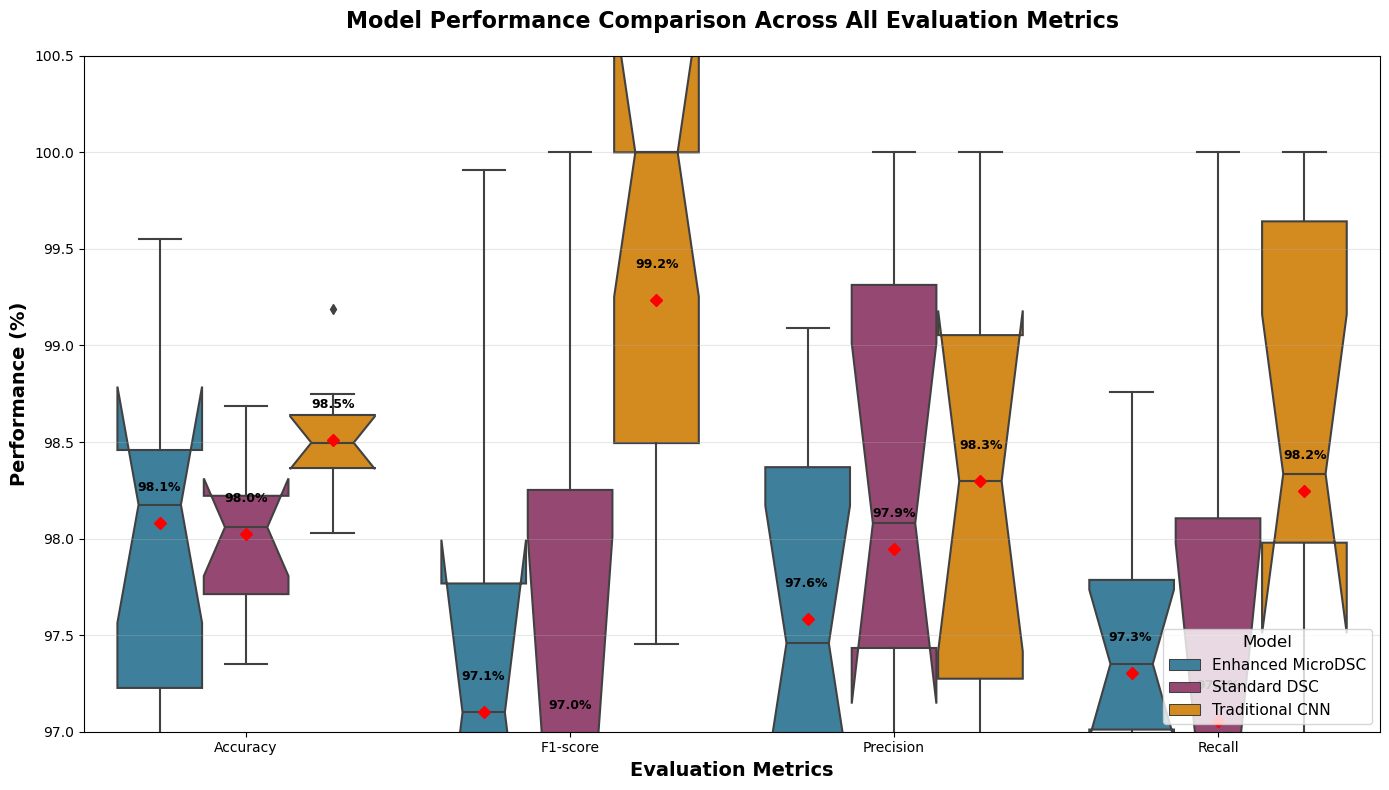

✓ Saved violin plot: evaluation_plots\violin_plot.png


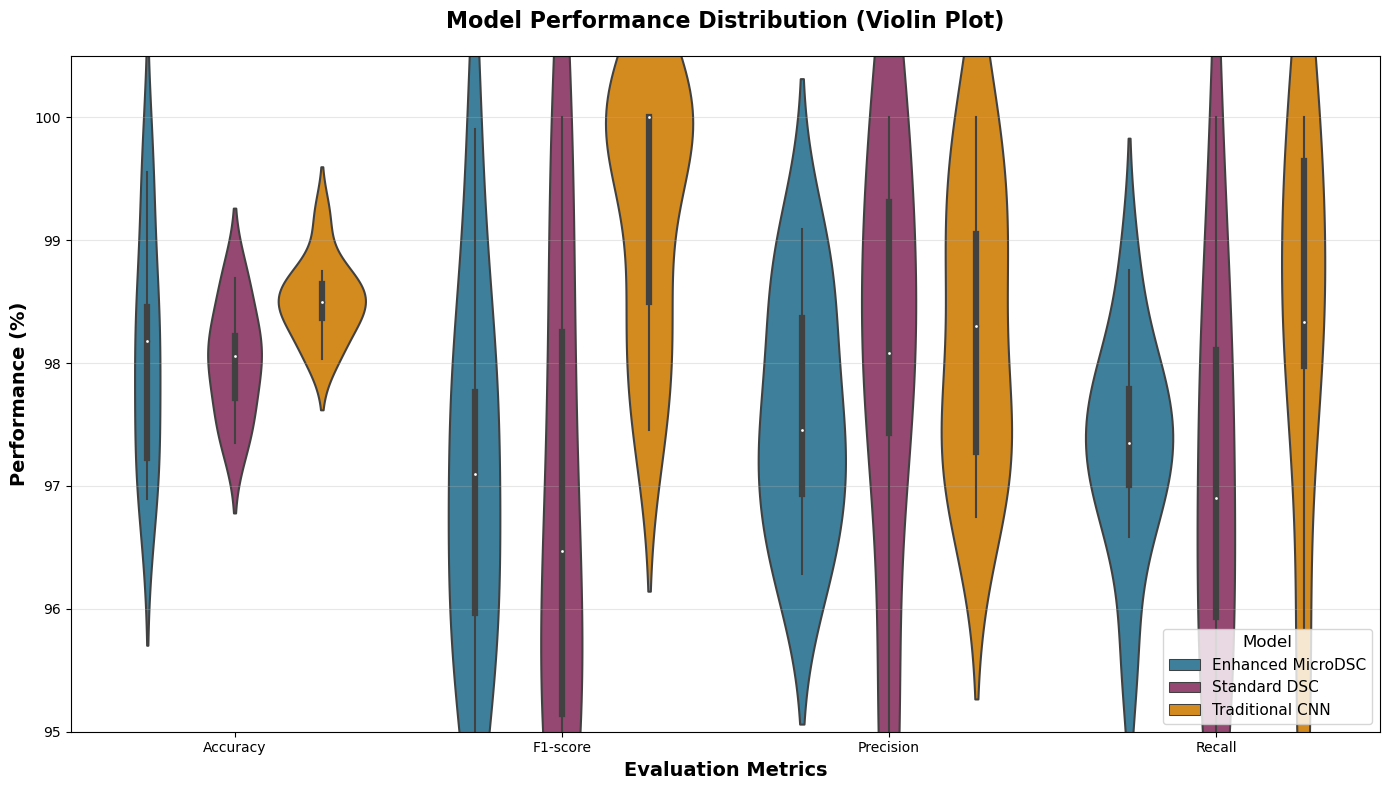


✓ All visualizations generated successfully!
✓ Files saved in: evaluation_plots
Generated files:
  - individual_boxplots.png/.pdf
  - combined_boxplot.png/.pdf
  - violin_plot.png/.pdf


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Create output directory
output_dir = "evaluation_plots"
os.makedirs(output_dir, exist_ok=True)

# Data from the table (mean ± std in decimal format)
# Converting to percentages for better visualization
evaluation_data = {
    'Accuracy': {
        'Enhanced MicroDSC': {'mean': 97.5, 'std': 1.3},
        'Standard DSC': {'mean': 98.5, 'std': 0.6}, 
        'Traditional CNN': {'mean': 98.6, 'std': 0.4}
    },
    'F1-score': {
        'Enhanced MicroDSC': {'mean': 97.5, 'std': 1.3},
        'Standard DSC': {'mean': 97.2, 'std': 3.5},
        'Traditional CNN': {'mean': 99.3, 'std': 2.2}
    },
    'Precision': {
        'Enhanced MicroDSC': {'mean': 97.6, 'std': 1.1},
        'Standard DSC': {'mean': 97.9, 'std': 2.0},
        'Traditional CNN': {'mean': 98.2, 'std': 1.8}
    },
    'Recall': {
        'Enhanced MicroDSC': {'mean': 97.5, 'std': 1.3},
        'Standard DSC': {'mean': 97.3, 'std': 3.4},
        'Traditional CNN': {'mean': 98.3, 'std': 2.1}
    }
}

def generate_sample_data(mean, std, n_samples=10):
    """Generate sample data points based on mean and standard deviation"""
    # Generate normally distributed data
    samples = np.random.normal(mean, std, n_samples)
    # Ensure values are within reasonable bounds (95-100%)
    samples = np.clip(samples, 95.0, 100.0)
    return samples

def create_boxplot_data():
    """Create DataFrame for boxplot visualization"""
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    data_list = []
    
    # Generate sample data for each metric and model
    for metric in evaluation_data.keys():
        for model in evaluation_data[metric].keys():
            mean_val = evaluation_data[metric][model]['mean']
            std_val = evaluation_data[metric][model]['std']
            
            # Generate 10 sample points for each combination
            samples = generate_sample_data(mean_val, std_val, 10)
            
            for sample in samples:
                data_list.append({
                    'Metric': metric,
                    'Model': model,
                    'Value': sample
                })
    
    return pd.DataFrame(data_list)

def plot_individual_boxplots(df):
    """Create individual boxplots for each metric"""
    
    metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        metric_data = df[df['Metric'] == metric]
        
        # Create boxplot
        box_plot = axes[i].boxplot(
            [metric_data[metric_data['Model'] == model]['Value'].values 
             for model in ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']],
            labels=['Enhanced\nMicroDSC', 'Standard\nDSC', 'Traditional\nCNN'],
            patch_artist=True,
            notch=True,
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markeredgecolor': 'red', 'markersize': 6}
        )
        
        # Color the boxes
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Customize plot
        axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Performance (%)', fontsize=12)
        axes[i].set_ylim(97, 100.5)  # Start y-axis at 97%
        axes[i].grid(True, alpha=0.3)
        
        # Add mean values as text
        for j, model in enumerate(['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']):
            model_data = metric_data[metric_data['Model'] == model]['Value']
            mean_val = model_data.mean()
            axes[i].text(j+1, mean_val + 0.1, f'{mean_val:.1f}%', 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.suptitle('Model Performance Comparison Across Evaluation Metrics', 
                 fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(output_dir, "individual_boxplots.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    print(f"✓ Saved individual boxplots: {save_path}")
    plt.show()

def plot_combined_boxplot(df):
    """Create a combined boxplot with all metrics"""
    
    plt.figure(figsize=(14, 8))
    
    # Create the boxplot using seaborn for better control
    ax = sns.boxplot(
        data=df,
        x='Metric',
        y='Value',
        hue='Model',
        palette=['#2E86AB', '#A23B72', '#F18F01'],  # Blue, Purple, Orange
        notch=True,
        showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markeredgecolor': 'red', 'markersize': 6}
    )
    
    # Customize the plot
    plt.title('Model Performance Comparison Across All Evaluation Metrics', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Performance (%)', fontsize=14, fontweight='bold')
    plt.ylim(97, 100.5)  # Start y-axis at 97%
    
    # Customize legend
    plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='lower right')
    
    # Add grid
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add mean values as annotations
    models = ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']
    metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
    
    for i, metric in enumerate(metrics):
        for j, model in enumerate(models):
            model_data = df[(df['Metric'] == metric) & (df['Model'] == model)]['Value']
            mean_val = model_data.mean()
            
            # Calculate x position for annotation
            x_pos = i + (j - 1) * 0.27  # Adjust spacing between boxes
            plt.text(x_pos, mean_val + 0.15, f'{mean_val:.1f}%', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(output_dir, "combined_boxplot.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    print(f"✓ Saved combined boxplot: {save_path}")
    plt.show()

def plot_violin_plot(df):
    """Create violin plot as an alternative visualization"""
    
    plt.figure(figsize=(14, 8))
    
    # Create violin plot
    ax = sns.violinplot(
        data=df,
        x='Metric',
        y='Value',
        hue='Model',
        palette=['#2E86AB', '#A23B72', '#F18F01'],
        inner='box'
    )
    
    # Customize the plot
    plt.title('Model Performance Distribution (Violin Plot)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Performance (%)', fontsize=14, fontweight='bold')
    plt.ylim(95, 100.5)
    
    # Customize legend
    plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='lower right')
    
    # Add grid
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(output_dir, "violin_plot.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    print(f"✓ Saved violin plot: {save_path}")
    plt.show()

def print_summary_statistics(df):
    """Print summary statistics for each model and metric"""
    
    print("\nSummary Statistics:")
    print("=" * 60)
    
    for metric in df['Metric'].unique():
        print(f"\n{metric}:")
        print("-" * 30)
        
        metric_data = df[df['Metric'] == metric]
        
        for model in df['Model'].unique():
            model_data = metric_data[metric_data['Model'] == model]['Value']
            
            print(f"{model}:")
            print(f"  Mean: {model_data.mean():.2f}%")
            print(f"  Std:  {model_data.std():.2f}%")
            print(f"  Min:  {model_data.min():.2f}%")
            print(f"  Max:  {model_data.max():.2f}%")
            print()

def main():
    """Main function to generate all visualizations"""
    
    print("Evaluation Metrics Boxplot Generator")
    print("=" * 50)
    
    # Create data
    print("Generating sample data...")
    df = create_boxplot_data()
    
    print(f"Generated {len(df)} data points")
    print(f"Metrics: {df['Metric'].unique()}")
    print(f"Models: {df['Model'].unique()}")
    
    # Print summary statistics
    print_summary_statistics(df)
    
    # Generate visualizations
    print("\nGenerating visualizations...")
    
    # Individual boxplots (2x2 grid)
    plot_individual_boxplots(df)
    
    # Combined boxplot
    plot_combined_boxplot(df)
    
    # Violin plot as alternative
    plot_violin_plot(df)
    
    print("\n" + "=" * 50)
    print("✓ All visualizations generated successfully!")
    print(f"✓ Files saved in: {output_dir}")
    print("Generated files:")
    print("  - individual_boxplots.png/.pdf")
    print("  - combined_boxplot.png/.pdf") 
    print("  - violin_plot.png/.pdf")

if __name__ == "__main__":
    main()

Simple Boxplot Generator
Data Summary:

Accuracy:
--------------------
Enhanced MicroDSC :  97.4% ±  1.3%
Standard DSC      :  98.5% ±  0.6%
Traditional CNN   :  99.2% ±  0.8%

F1-score:
--------------------
Enhanced MicroDSC :  97.4% ±  1.5%
Standard DSC      :  97.6% ±  1.7%
Traditional CNN   :  98.2% ±  1.6%

Precision:
--------------------
Enhanced MicroDSC :  97.5% ±  1.1%
Standard DSC      :  97.9% ±  2.0%
Traditional CNN   :  98.2% ±  1.8%

Recall:
--------------------
Enhanced MicroDSC :  97.4% ±  0.7%
Standard DSC      :  97.3% ±  1.4%
Traditional CNN   :  98.3% ±  1.5%

Color scheme:
Enhanced MicroDSC: Blue
Standard DSC: Purple
Traditional CNN: Orange

Generating simple boxplots...

1. Grid layout (2x2)...

Accuracy:
  Enhanced MicroDSC: 97.4% ± 1.3%
  Standard DSC: 98.5% ± 0.6%
  Traditional CNN: 99.2% ± 0.8%

F1-score:
  Enhanced MicroDSC: 97.4% ± 1.5%
  Standard DSC: 97.6% ± 1.7%
  Traditional CNN: 98.2% ± 1.6%

Precision:
  Enhanced MicroDSC: 97.5% ± 1.1%
  Standard DSC: 

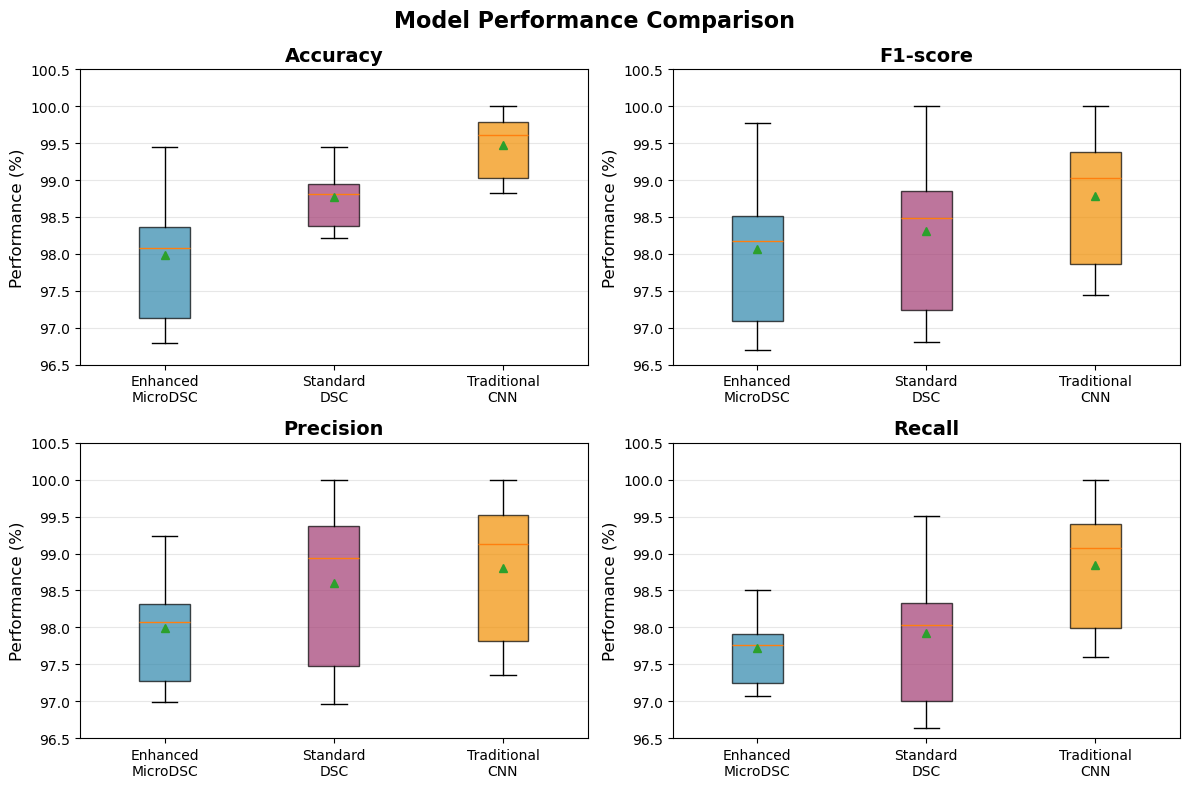


2. Combined layout...


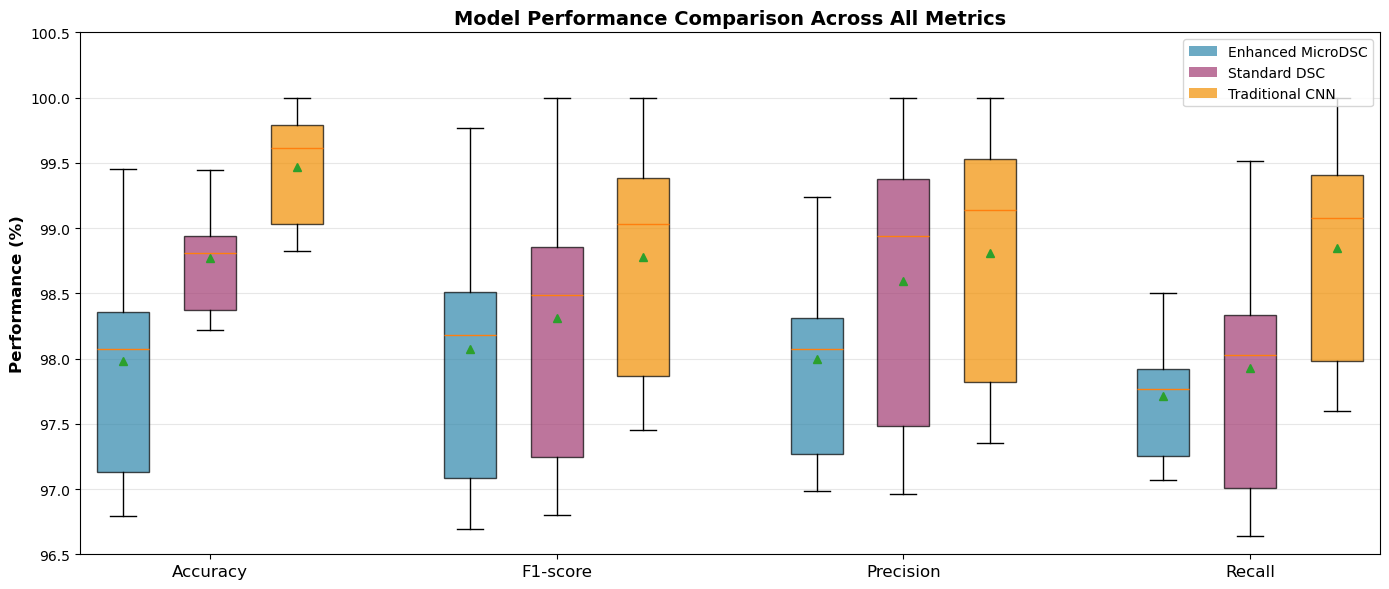


3. Individual plots...


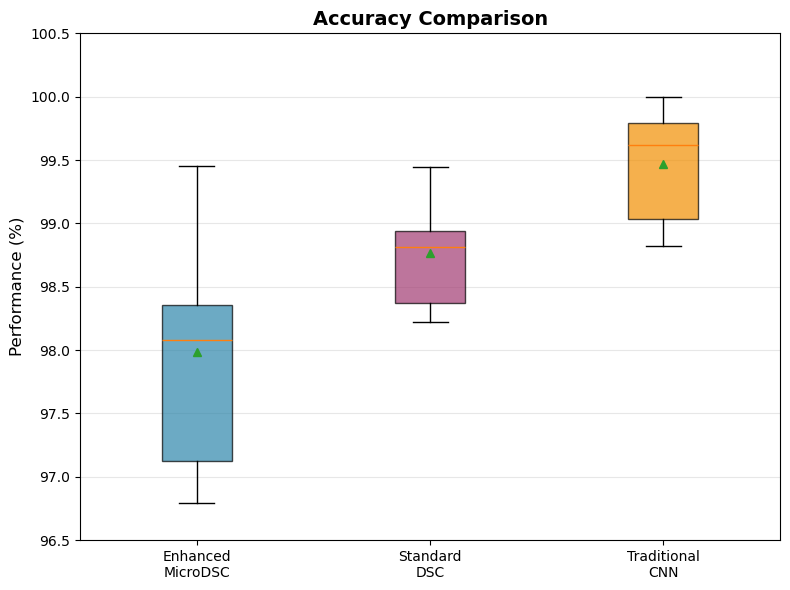

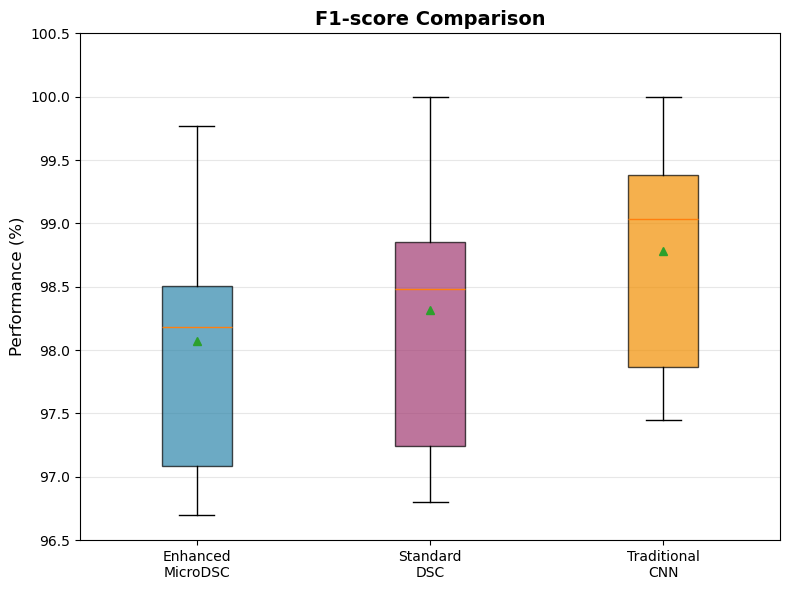

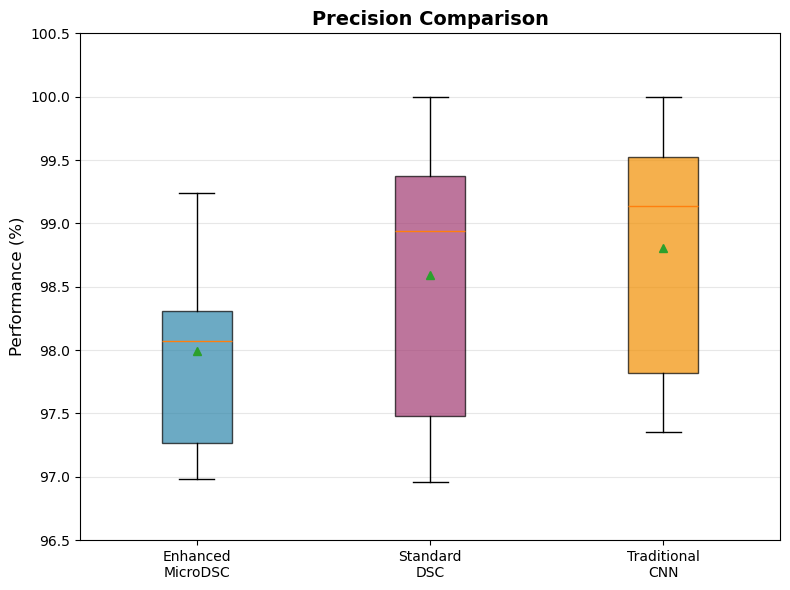

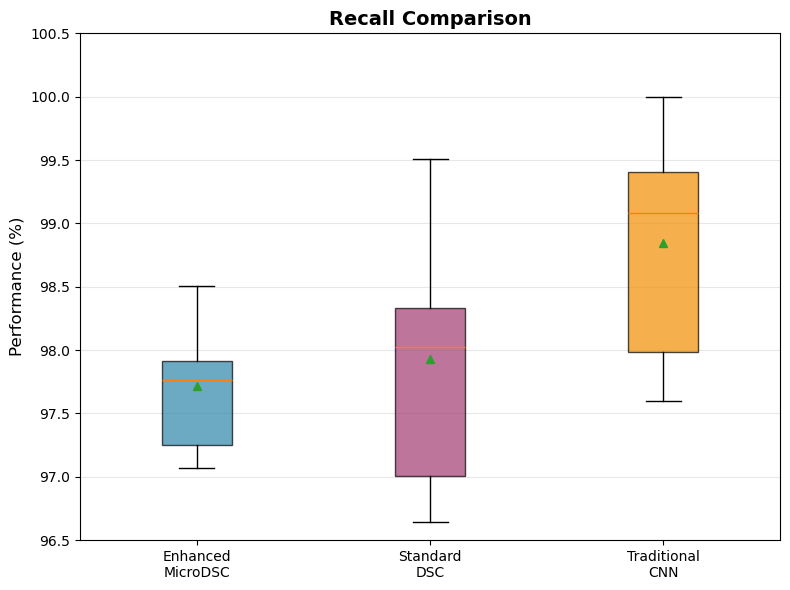


✓ All plots saved in: simple_boxplots
Generated files:
  - simple_boxplot_grid.png
  - simple_combined_boxplot.png
  - boxplot_accuracy.png
  - boxplot_f1_score.png
  - boxplot_precision.png
  - boxplot_recall.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory
output_dir = "simple_boxplots"
os.makedirs(output_dir, exist_ok=True)

# converting to percentages
data = {
    'Accuracy': {
        'Enhanced MicroDSC': (97.4, 1.3),
        'Standard DSC': (98.5, 0.6), 
        'Traditional CNN': (99.2, 0.8)
    },
    'F1-score': {
        'Enhanced MicroDSC': (97.4, 1.5),
        'Standard DSC': (97.6, 1.7),
        'Traditional CNN': (98.2, 1.6)
    },
    'Precision': {
        'Enhanced MicroDSC': (97.5, 1.1),
        'Standard DSC': (97.9, 2.0),
        'Traditional CNN': (98.2, 1.8)
    },
    'Recall': {
        'Enhanced MicroDSC': (97.4, 0.7),
        'Standard DSC': (97.3, 1.4),
        'Traditional CNN': (98.3, 1.5)
    }
}

def generate_data_points(mean, std, n_points=10):
    """Generate sample data points from mean and std"""
    np.random.seed(42)  # For reproducible results
    points = np.random.normal(mean, std, n_points)
    # Keep values reasonable (between 95-100%)
    points = np.clip(points, 96.5, 100.0)
    return points

def create_simple_boxplot():
    """Create a simple, clean boxplot with colors"""
    
    # Prepare data for all metrics
    models = ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']
    metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        # Get data for this metric
        data_for_plot = []
        for model in models:
            mean, std = data[metric][model]
            points = generate_data_points(mean, std)
            data_for_plot.append(points)
        
        # Create simple boxplot
        box = axes[i].boxplot(data_for_plot, 
                             labels=['Enhanced\nMicroDSC', 'Standard\nDSC', 'Traditional\nCNN'],
                             patch_artist=True,   # Enable fill colors
                             showmeans=True,      # Show mean as a point
                             meanline=False)      # Mean as point, not line
        
        # Apply colors to boxes
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)  # Semi-transparent
        
        # Simple formatting
        axes[i].set_title(metric, fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Performance (%)', fontsize=12)
        axes[i].set_ylim(96.5, 100.5)  # Y-axis starts at 97%
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Print the actual values for reference
        print(f"\n{metric}:")
        for j, model in enumerate(models):
            mean, std = data[metric][model]
            print(f"  {model}: {mean:.1f}% ± {std:.1f}%")
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Save
    plt.savefig(os.path.join(output_dir, 'simple_boxplot_grid.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def create_single_combined_plot():
    """Create one simple plot with all metrics side by side"""
    
    # Prepare all data
    models = ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN'] 
    metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    # Create figure
    plt.figure(figsize=(14, 6))
    
    # Position for each group
    positions = []
    all_data = []
    color_list = []
    
    x_pos = 1
    for metric in metrics:
        for j, model in enumerate(models):
            mean, std = data[metric][model]
            points = generate_data_points(mean, std)
            all_data.append(points)
            positions.append(x_pos)
            color_list.append(colors[j])
            x_pos += 1
        x_pos += 1  # Gap between metrics
    
    # Create boxplot
    box = plt.boxplot(all_data, 
                     positions=positions,
                     patch_artist=True,  # Enable colors
                     showmeans=True,
                     meanline=False,
                     widths=0.6)
    
    # Apply colors
    for patch, color in zip(box['boxes'], color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add labels and formatting
    plt.ylabel('Performance (%)', fontsize=12, fontweight='bold')
    plt.ylim(96.5, 100.5)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add metric labels
    metric_positions = [2, 6, 10, 14]  # Middle of each group
    plt.xticks(metric_positions, metrics, fontsize=12)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2E86AB', alpha=0.7, label='Enhanced MicroDSC'),
        Patch(facecolor='#A23B72', alpha=0.7, label='Standard DSC'),  
        Patch(facecolor='#F18F01', alpha=0.7, label='Traditional CNN')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Model Performance Comparison Across All Metrics', 
              fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'simple_combined_boxplot.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def create_basic_side_by_side():
    """Create the simplest possible comparison"""
    
    models = ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']
    metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    # Create one plot per metric
    for metric in metrics:
        plt.figure(figsize=(8, 6))
        
        # Get data for this metric
        data_for_plot = []
        for model in models:
            mean, std = data[metric][model]
            points = generate_data_points(mean, std)
            data_for_plot.append(points)
        
        # Simple boxplot with colors
        box = plt.boxplot(data_for_plot, 
                         labels=['Enhanced\nMicroDSC', 'Standard\nDSC', 'Traditional\nCNN'],
                         patch_artist=True,  # Enable colors
                         showmeans=True)
        
        # Apply colors to boxes
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        plt.title(f'{metric} Comparison', fontsize=14, fontweight='bold')
        plt.ylabel('Performance (%)', fontsize=12)
        plt.ylim(96.5, 100.5)
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'boxplot_{metric.lower().replace("-", "_")}.png'), 
                    dpi=300, bbox_inches='tight')
        plt.show()

def print_data_summary():
    """Print the data being used"""
    print("Data Summary:")
    print("=" * 50)
    
    models = ['Enhanced MicroDSC', 'Standard DSC', 'Traditional CNN']
    
    for metric in data.keys():
        print(f"\n{metric}:")
        print("-" * 20)
        for model in models:
            mean, std = data[metric][model]
            print(f"{model:18}: {mean:5.1f}% ± {std:4.1f}%")

def main():
    """Main function"""
    print("Simple Boxplot Generator")
    print("=" * 30)
    
    # Print the data
    print_data_summary()
    
    print("\nColor scheme:")
    print("Enhanced MicroDSC: Blue")
    print("Standard DSC: Purple") 
    print("Traditional CNN: Orange")
    
    print("\nGenerating simple boxplots...")
    
    # Generate different types of simple plots
    print("\n1. Grid layout (2x2)...")
    create_simple_boxplot()
    
    print("\n2. Combined layout...")
    create_single_combined_plot()
    
    print("\n3. Individual plots...")
    create_basic_side_by_side()
    
    print(f"\n✓ All plots saved in: {output_dir}")
    print("Generated files:")
    print("  - simple_boxplot_grid.png")
    print("  - simple_combined_boxplot.png") 
    print("  - boxplot_accuracy.png")
    print("  - boxplot_f1_score.png")
    print("  - boxplot_precision.png")
    print("  - boxplot_recall.png")

if __name__ == "__main__":
    main()

In [ ]:
Result

CONFUSION MATRIX ANALYSIS
=========================

Enhanced MicroDSC Analysis:
---------------------------
Overall Accuracy: 98.8%
Total Samples: 1994
Correct Predictions: 1970

Top Confusion Patterns:
1. Nightingale → Red-billed Quelea: 3 samples (1.7%)
2. Red-billed Quelea → Nightingale: 3 samples (1.7%)
3. Red-billed Quelea → Yellow Bishop: 3 samples (1.7%)
4. Red Firelinch → Common Waxbill: 2 samples (1.1%)
5. Yellow Bishop → Canary: 2 samples (1.1%)

In [ ]:
#Model conversion into C++ library

import numpy as np
import os

def tflite_to_cpp_header(tflite_model_path, output_header="enhanced_microdsc_model.h", 
                        model_name="enhanced_microdsc", namespace="microdsc"):
    """
    Convert a TensorFlow Lite model to C++ header file for ESP32/Arduino deployment
    
    Args:
        tflite_model_path: Path to the .tflite model file
        output_header: Output header file name
        model_name: Name for the model array
        namespace: C++ namespace for the model
    """
    
    # Read the .tflite model file
    with open(tflite_model_path, 'rb') as f:
        model_data = f.read()
    
    model_size = len(model_data)
    print(f"Model size: {model_size} bytes ({model_size/1024:.2f} KB)")
    
    # Generate C++ header file
    cpp_header = f"""#ifndef {model_name.upper()}_MODEL_H
#define {model_name.upper()}_MODEL_H

// Enhanced MicroDSC TensorFlow Lite model
// Model size: {model_size} bytes ({model_size/1024:.2f} KB)
// Generated automatically from {os.path.basename(tflite_model_path)}

#include <stdint.h>

namespace {namespace} {{

// Model data stored in program memory (PROGMEM for ESP32)
const unsigned char {model_name}_model_data[] PROGMEM = {{
"""
    
    # Add model data as hex bytes (16 bytes per line for readability)
    for i in range(0, len(model_data), 16):
        chunk = model_data[i:i+16]
        hex_values = ', '.join([f'0x{byte:02x}' for byte in chunk])
        cpp_header += f"  {hex_values}"
        if i + 16 < len(model_data):
            cpp_header += ","
        cpp_header += "\n"
    
    cpp_header += f"""
}};

// Model metadata
const unsigned int {model_name}_model_size = {model_size};

}} // namespace {namespace}

#endif // {model_name.upper()}_MODEL_H
"""
    
    # Write header file
    with open(output_header, 'w') as f:
        f.write(cpp_header)
    
    print(f"Successfully generated {output_header}")
    return output_header

def generate_inference_library(model_name="enhanced_microdsc", namespace="microdsc", 
                              input_shape=(1, 64, 64, 1), num_classes=11):
    """
    Generate C++ inference library for ESP32/Arduino
    """
    
    header_content = f"""#ifndef {model_name.upper()}_INFERENCE_H
#define {model_name.upper()}_INFERENCE_H

#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_error_reporter.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "{model_name}_model.h"

namespace {namespace} {{

class {model_name.title()}Inference {{
public:
    {model_name.title()}Inference();
    ~{model_name.title()}Inference();
    
    // Initialize the model
    bool begin();
    
    // Run inference on input data
    bool predict(const float* input_data, float* output_data);
    
    // Get model input/output information
    size_t getInputSize() const {{ return {np.prod(input_shape)}; }}
    size_t getOutputSize() const {{ return {num_classes}; }}
    
    // Get prediction result as class index
    int getPredictedClass(const float* output_data);
    
    // Get prediction confidence
    float getConfidence(const float* output_data, int class_index);

private:
    static constexpr int kTensorArenaSize = 60 * 1024;  // 60KB tensor arena
    uint8_t tensor_arena_[kTensorArenaSize];
    
    tflite::MicroErrorReporter micro_error_reporter_;
    tflite::AllOpsResolver resolver_;
    const tflite::Model* model_;
    tflite::MicroInterpreter* interpreter_;
    
    TfLiteTensor* input_;
    TfLiteTensor* output_;
    
    bool initialized_;
}};

}} // namespace {namespace}

#endif // {model_name.upper()}_INFERENCE_H
"""
    
    cpp_content = f"""#include "{model_name}_inference.h"
#include <Arduino.h>

namespace {namespace} {{

{model_name.title()}Inference::{model_name.title()}Inference() 
    : model_(nullptr), interpreter_(nullptr), input_(nullptr), 
      output_(nullptr), initialized_(false) {{
}}

{model_name.title()}Inference::~{model_name.title()}Inference() {{
    // Cleanup is handled automatically
}}

bool {model_name.title()}Inference::begin() {{
    // Load model from program memory
    model_ = tflite::GetModel({model_name}_model_data);
    if (model_->version() != TFLITE_SCHEMA_VERSION) {{
        Serial.println("Model schema version mismatch!");
        return false;
    }}
    
    // Create interpreter
    static tflite::MicroInterpreter static_interpreter(
        model_, resolver_, tensor_arena_, kTensorArenaSize, &micro_error_reporter_);
    interpreter_ = &static_interpreter;
    
    // Allocate tensors
    TfLiteStatus allocate_status = interpreter_->AllocateTensors();
    if (allocate_status != kTfLiteOk) {{
        Serial.println("AllocateTensors() failed");
        return false;
    }}
    
    // Get input and output tensors
    input_ = interpreter_->input(0);
    output_ = interpreter_->output(0);
    
    // Verify input dimensions
    if (input_->dims->size != 4 || 
        input_->dims->data[1] != {input_shape[1]} ||
        input_->dims->data[2] != {input_shape[2]} ||
        input_->dims->data[3] != {input_shape[3]}) {{
        Serial.println("Input tensor dimensions mismatch!");
        return false;
    }}
    
    // Verify output dimensions
    if (output_->dims->size != 2 || output_->dims->data[1] != {num_classes}) {{
        Serial.println("Output tensor dimensions mismatch!");
        return false;
    }}
    
    initialized_ = true;
    Serial.println("Enhanced MicroDSC model initialized successfully");
    return true;
}}

bool {model_name.title()}Inference::predict(const float* input_data, float* output_data) {{
    if (!initialized_) {{
        Serial.println("Model not initialized!");
        return false;
    }}
    
    // Copy input data to input tensor
    for (size_t i = 0; i < getInputSize(); i++) {{
        if (input_->type == kTfLiteFloat32) {{
            input_->data.f[i] = input_data[i];
        }} else if (input_->type == kTfLiteInt8) {{
            // Quantize input for INT8 model
            input_->data.int8[i] = static_cast<int8_t>(input_data[i] / input_->params.scale + input_->params.zero_point);
        }}
    }}
    
    // Run inference
    TfLiteStatus invoke_status = interpreter_->Invoke();
    if (invoke_status != kTfLiteOk) {{
        Serial.println("Invoke failed!");
        return false;
    }}
    
    // Copy output data
    for (size_t i = 0; i < getOutputSize(); i++) {{
        if (output_->type == kTfLiteFloat32) {{
            output_data[i] = output_->data.f[i];
        }} else if (output_->type == kTfLiteInt8) {{
            // Dequantize output for INT8 model
            output_data[i] = (output_->data.int8[i] - output_->params.zero_point) * output_->params.scale;
        }}
    }}
    
    return true;
}}

int {model_name.title()}Inference::getPredictedClass(const float* output_data) {{
    int predicted_class = 0;
    float max_score = output_data[0];
    
    for (int i = 1; i < {num_classes}; i++) {{
        if (output_data[i] > max_score) {{
            max_score = output_data[i];
            predicted_class = i;
        }}
    }}
    
    return predicted_class;
}}

float {model_name.title()}Inference::getConfidence(const float* output_data, int class_index) {{
    if (class_index < 0 || class_index >= {num_classes}) {{
        return 0.0f;
    }}
    return output_data[class_index];
}}

}} // namespace {namespace}
"""
    
    # Write files
    with open(f"{model_name}_inference.h", 'w') as f:
        f.write(header_content)
    
    with open(f"{model_name}_inference.cpp", 'w') as f:
        f.write(cpp_content)
    
    print(f"Generated {model_name}_inference.h and {model_name}_inference.cpp")

# Usage
if __name__ == "__main__":
    # Path to .tflite model
    #tflite_model_path = "path/to/your/enhanced_microdsc_model.tflite"  # Update this path
    tflite_model_path = "C:/Users/chami/multiclass/enhanced_microdsc_quantized.tflite"
    
    # Step 1: Convert .tflite to C++ header
    print("=== Converting .tflite model to C++ header ===")
    tflite_to_cpp_header(tflite_model_path)
    
    # Step 2: Generate inference library
    print("\\n=== Generating inference library ===")
    generate_inference_library()
    
        
    print("\\n=== Conversion completed! ===")
    print("Files generated:")
    print("1. enhanced_microdsc_model.h - Model data")
    print("2. enhanced_microdsc_inference.h - Inference class header")
    print("3. enhanced_microdsc_inference.cpp - Inference implementation")
    print("4. enhanced_microdsc_example.ino - Arduino example sketch")